# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [2]:
# ---------- Standard Library ----------
import os
import time
import math
import random
from pathlib import Path
from collections import Counter

# Environment (set BEFORE importing TensorFlow)
os.environ["PYTHONHASHSEED"] = "0"        # Disable hash randomization
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # Deterministic TF ops where possible
os.environ["TF_CUDNN_DETERMINISM"] = "1"  # Deterministic CuDNN (if GPU)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Suppress TF INFO/WARNING logs

# ---------- Third-Party (General) ----------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit, ShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

# ---------- Scikit-learn ----------
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# ---------- TensorFlow / Keras ----------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers, initializers, optimizers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.layers import GlobalMaxPooling1D, SpatialDropout1D, Bidirectional
# Layers (vision)
from tensorflow.keras.layers import (
    Input, Conv2D,Conv1D, SeparableConv2D, MaxPooling2D, GlobalAveragePooling2D,
    GlobalMaxPooling2D, BatchNormalization, ReLU, Flatten, Dense, Dropout
)

# Preprocessing (vision)
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ---------- (Optional) NLP-related imports ----------
# If not doing NLP, you can safely remove this block.
from tensorflow.keras.layers import (
    Embedding, GlobalAveragePooling1D, LSTM, GRU, SpatialDropout1D, Bidirectional, Lambda
)
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.datasets import imdb  # uncomment only if needed

# ---------- Reproducibility ----------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)  # covers TF, Python, and NumPy RNGs

# ---------- Convenience ----------
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

def format_hms(seconds: float) -> str:
    """Format seconds as H:MM:SS."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# Example:
# start = time.time()
# ... your code ...
# print("Elapsed:", format_hms(time.time() - start))


In [3]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

In [19]:
### Define Helper Functions

BATCH_SIZE = 64
results = {}

class LRSchedulerLogger(Callback):
    _supports_tf_logs = True
    def on_train_begin(self, logs=None):
        self.lrs = []
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            current_step = tf.cast(self.model.optimizer.iterations, tf.float32)
            lr = lr(current_step).numpy()
        else:
            lr = tf.keras.backend.get_value(lr)
        self.lrs.append(float(lr))

def plot_learning_curves(hist, title="Learning Curves", lr_logger=None):
    val_losses = hist.history['val_loss']
    min_val_epoch = val_losses.index(min(val_losses))
    val_loss_at_min = val_losses[min_val_epoch]
    val_acc_at_min = hist.history['val_accuracy'][min_val_epoch]

    n_epochs = len(val_losses)
    epochs = list(range(1, n_epochs + 1))
    tick_interval = max(1, n_epochs // 20)
    xticks = list(range(0, n_epochs + 1, tick_interval))

    n_subplots = 3 if lr_logger is not None else 2
    plt.figure(figsize=(8, 10 if n_subplots == 3 else 8))

    plt.subplot(n_subplots, 1, 1)
    plt.plot(epochs, hist.history['loss'], label='Train Loss')
    plt.plot(epochs, hist.history['val_loss'], label='Val Loss')
    plt.scatter(min_val_epoch + 1, val_loss_at_min, color='red', marker='x', s=50, label='Min Val Loss')
    plt.title(f'{title} - Loss'); plt.ylabel('Loss')
    plt.xticks(xticks); plt.legend(); plt.grid(True)

    plt.subplot(n_subplots, 1, 2)
    plt.plot(epochs, hist.history['accuracy'], label='Train Accuracy')
    plt.plot(epochs, hist.history['val_accuracy'], label='Val Accuracy')
    plt.scatter(min_val_epoch + 1, val_acc_at_min, color='red', marker='x', s=50, label='Acc @ Min Val Loss')
    plt.title(f'{title} - Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.xticks(xticks); plt.legend(); plt.grid(True)

    if lr_logger is not None:
        plt.subplot(n_subplots, 1, 3)
        plt.plot(epochs, lr_logger.lrs, color='gray', label='Learning Rate')
        plt.title(f'{title} - Learning Rate'); plt.xlabel('Epoch'); plt.ylabel('LR')
        plt.xticks(xticks); plt.legend(); plt.grid(True)

    plt.tight_layout(); plt.show()

    print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
    print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
    print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
    print(f"Minimum Validation Loss:        {val_loss_at_min:.4f} (Epoch {min_val_epoch + 1})")
    print(f"Validation Accuracy @ Min Loss: {val_acc_at_min:.4f}")

    results[title] = (val_acc_at_min, min_val_epoch + 1)

def evaluate_model(model, X, y_true, categories, model_name="Model"):
    res = model.evaluate(X, y_true, verbose=0)
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = res[1]
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  Macro F1:    {macro_f1:.4f}")
    print(f"  Weighted F1: {weighted_f1:.4f}")
    print(f"  Loss:        {res[0]:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(
        y_true, y_pred, target_names=categories, digits=3, zero_division=0
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(categories)))
    ax.set_yticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=90, fontsize=7)
    ax.set_yticklabels(categories, fontsize=7)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

    return acc, macro_f1, weighted_f1

def print_metrics():
    print(f"\n{'='*55}")
    print(f"{'Model':<40} {'Acc':>6} {'Epoch':>6}")
    print(f"{'='*55}")
    for title, (acc, ep) in sorted(results.items(),
                                   key=lambda kv: kv[1][0],
                                   reverse=True):
        print(f"{title:<40}\t{acc:.4f} @ {ep}")

def train_and_test(model, X_train, y_train, X_val, y_val, X_test, y_test,
                   title="Learning Curves",
                   epochs=30,
                   lr_schedule=1e-3,
                   optimizer="Adam",
                   loss="sparse_categorical_crossentropy",
                   batch_size=BATCH_SIZE,
                   class_weight=None,
                   use_early_stopping=True,
                   patience=5,
                   min_delta=1e-4,
                   use_reduce_lr=False,
                   reduce_lr_patience=5,
                   reduce_lr_factor=0.5,
                   reduce_lr_min=1e-8,
                   log_learning_rate=True,
                   callbacks=None,
                   verbose=1,
                   return_history=True):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")

    cbs = list(callbacks) if callbacks is not None else []

    if isinstance(optimizer, str):
        if optimizer.lower() == "adam":
            opt = Adam(learning_rate=lr_schedule)
        else:
            opt = optimizer
    else:
        opt = optimizer

    model.compile(
    optimizer=opt,
    loss=loss,
    metrics=["accuracy",])

    if use_early_stopping:
        cbs.append(EarlyStopping(
            monitor="val_loss", patience=patience, min_delta=min_delta,
            restore_best_weights=True, verbose=verbose
        ))

    if use_reduce_lr:
        cbs.append(ReduceLROnPlateau(
            monitor="val_loss", factor=reduce_lr_factor,
            patience=reduce_lr_patience, min_delta=1e-5,
            cooldown=0, min_lr=reduce_lr_min, verbose=verbose
        ))

    lr_logger = None
    if log_learning_rate:
        lr_logger = LRSchedulerLogger()
        cbs.append(lr_logger)

    start = time.time()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=cbs,
        verbose=verbose
    )

    elapsed = time.time() - start

    plot_learning_curves(history, title=title, lr_logger=lr_logger)

    print(f"\n--- Validation Set ---")
    val_acc, val_f1, val_wf1 = evaluate_model(
        model, X_val, y_val, categories, f"{title} (Val)")

    print(f"\n--- Test Set ---")
    test_acc, test_f1, test_wf1 = evaluate_model(
        model, X_test, y_test, categories, f"{title} (Test)")

    n_params = model.count_params()
    n_epochs = len(history.history["loss"])
    print(f"\nParameters:    {n_params:,}")
    print(f"Epochs trained: {n_epochs}")
    print(f"Training time:  {format_hms(elapsed)}")

    if return_history:
        return {
            "history": history, "time": elapsed, "epochs": n_epochs,
            "params": n_params, "lr_logger": lr_logger,
            "val_acc": val_acc, "val_f1": val_f1,
            "test_acc": test_acc, "test_f1": test_f1,
        }

#### Load Dataset

In [5]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


In [6]:
df = huff_all.to_pandas()

num_samples = len(df)
num_classes = df["category"].nunique()
print(f"Total articles : {num_samples:,}")
print(f"Unique categories : {num_classes}")
print(f"Columns        : {list(df.columns)}")

Total articles : 200,853
Unique categories : 41
Columns        : ['category', 'headline', 'authors', 'link', 'short_description', 'date']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200853 entries, 0 to 200852
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype        
---  ------             --------------   -----        
 0   category           200853 non-null  object       
 1   headline           200853 non-null  object       
 2   authors            200853 non-null  object       
 3   link               200853 non-null  object       
 4   short_description  200853 non-null  object       
 5   date               200853 non-null  datetime64[s]
dtypes: datetime64[s](1), object(5)
memory usage: 9.2+ MB


#### Concat Headline + Short Description

In [8]:
df["text"] = (
    df["headline"].fillna("").str.strip()
    + " [SEP] "
    + df["short_description"].fillna("").str.strip()
).str.lower()

#### Clean Dataset

In [9]:
### Drop rows with empty headlines
mask_empty = df["headline"].fillna("").str.strip() == ""
df = df[~mask_empty].copy()

### Drop duplicate text
n_dup = df.duplicated(subset=["text"]).sum()
df = df.drop_duplicates(subset=["text"]).copy()
df = df.reset_index(drop=True)
print(f"Clean dataset size: {len(df):,}")

Clean dataset size: 200,356


#### Merge Redundant Categories

In [10]:
label_map = {
    "WORLDPOST": "WORLD NEWS",
    "THE WORLDPOST": "WORLD NEWS",
    "ARTS": "ARTS & CULTURE",
    "CULTURE & ARTS": "ARTS & CULTURE",
    "STYLE": "STYLE & BEAUTY",
    "HEALTHY LIVING": "WELLNESS",
    "PARENTS": "PARENTING",
    "COLLEGE": "EDUCATION",
    "GREEN": "ENVIRONMENT",
    "TASTE": "FOOD & DRINK",
    "BUSINESS": "BUSINESS & FINANCES",
    "MONEY": "BUSINESS & FINANCES",
    "SCIENCE": "SCIENCE & TECH",
    "TECH": "SCIENCE & TECH",
    "BLACK VOICES": "IDENTITY",
    "LATINO VOICES": "IDENTITY",
    "QUEER VOICES": "IDENTITY",
    "WOMAN": "IDENTITY",
}
df["category"] = df["category"].replace(label_map)
print(f"\nAfter merging: {df['category'].nunique()} categories")


After merging: 27 categories


#### Drop Redundant Fields

In [11]:
df = df[["text", "category"]]

#### Encode Category Labels

In [12]:
label_names = sorted(df["category"].unique().tolist())
num_classes  = len(label_names)
label2idx    = {name: idx for idx, name in enumerate(label_names)}
idx2label    = {idx: name for name, idx in label2idx.items()}

df["label"] = df["category"].map(label2idx)

print(f"Number of classes: {num_classes}")
print("Label mapping:")
for name, idx in label2idx.items():
    print(f"  {idx:>2}  {name}")

Number of classes: 27
Label mapping:
   0  ARTS & CULTURE
   1  BUSINESS & FINANCES
   2  COMEDY
   3  CRIME
   4  DIVORCE
   5  EDUCATION
   6  ENTERTAINMENT
   7  ENVIRONMENT
   8  FIFTY
   9  FOOD & DRINK
  10  GOOD NEWS
  11  HOME & LIVING
  12  IDENTITY
  13  IMPACT
  14  MEDIA
  15  PARENTING
  16  POLITICS
  17  RELIGION
  18  SCIENCE & TECH
  19  SPORTS
  20  STYLE & BEAUTY
  21  TRAVEL
  22  WEDDINGS
  23  WEIRD NEWS
  24  WELLNESS
  25  WOMEN
  26  WORLD NEWS


#### Train/Val/Test Split

In [13]:
train_df, test_df = train_test_split(df, test_size=0.10, random_state=random_seed, stratify=df["label"])
train_df, val_df = train_test_split(train_df, test_size=1/9, random_state=random_seed, stratify=train_df["label"])

X_train = tf.constant(train_df["text"].values)
X_val   = tf.constant(val_df["text"].values)
X_test  = tf.constant(test_df["text"].values)
y_train = train_df["label"].values.astype(np.int32)
y_val   = val_df["label"].values.astype(np.int32)
y_test  = test_df["label"].values.astype(np.int32)

print(f"\nSplit sizes:")
print(f"  Train: {len(X_train):,}")
print(f"  Val:   {len(X_val):,}")
print(f"  Test:  {len(X_test):,}")

print("\nStratification check:")
for name, ys in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    dist = np.bincount(ys, minlength=num_classes) / len(ys) * 100
    print(f"  {name} — min class: {dist.min():.2f}%, max: {dist.max():.2f}%")


Split sizes:
  Train: 160,284
  Val:   20,036
  Test:  20,036

Stratification check:
  Train — min class: 0.70%, max: 16.33%
  Val — min class: 0.70%, max: 16.33%
  Test — min class: 0.70%, max: 16.33%


#### Text Tokenization

In [14]:
MAX_TOKENS = 20_000 ## 20k most common tokens
MAX_LEN = 64 ## 95th percentile of text lengths

vectorize_layer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN,
)
vectorize_layer.adapt(X_train)

In [15]:
X_train_vec = vectorize_layer(X_train).numpy()
total_tokens = np.sum(X_train_vec > 0)
oov_tokens = np.sum(X_train_vec == 1)
print(f"OOV rate: {oov_tokens / total_tokens * 100:.2f}%")

OOV rate: 4.20%


#### Class Weights to Address Class Imbalance

Imbalance ratio (max/median): 2.98
Weight range: [0.227, 5.310]


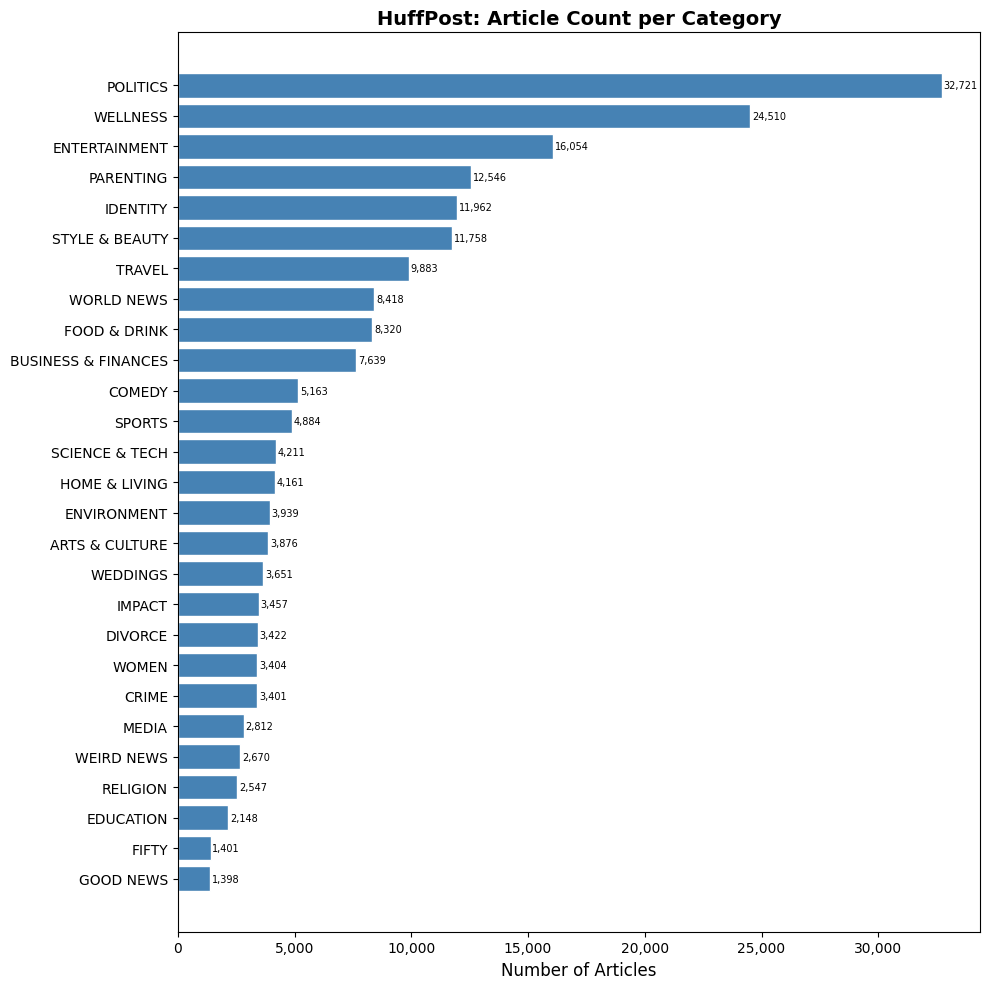

Saved: class_distribution.png


In [16]:
class_weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print(f"Imbalance ratio (max/median): {class_weights.max() / np.median(class_weights):.2f}")
print(f"Weight range: [{class_weights.min():.3f}, {class_weights.max():.3f}]")

# Class distribution chart — sorted descending
cat_counts = df["category"].value_counts()
colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(cat_counts)))

fig, ax = plt.subplots(figsize=(10, 10))
cat_sorted = cat_counts.sort_values(ascending=True)   # largest bar at top
bars = ax.barh(cat_sorted.index, cat_sorted.values, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of Articles", fontsize=12)
ax.set_title("HuffPost: Article Count per Category", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, cnt in zip(bars, cat_sorted.values):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}", va="center", fontsize=7)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: class_distribution.png")

In [21]:
categories = label_names

### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**

We loaded the HuffPost News Category dataset directly from Hugging Face using `load_dataset("json", data_files=URL, split="train")`, which gave us 200,853 articles with fields like headline, short_description, category, authors, link, and date. We then converted it to a pandas DataFrame for easier manipulation.

For cleaning, we first concatenated the headline and short_description fields into a single text column using the format `headline [SEP] short_description`, lowercased everything, and stripped whitespace — this gives the model a unified input and addresses the ~19,700 rows with empty short descriptions that we identified in Milestone 1 by still preserving the headline signal. We then dropped the 6 rows with completely empty headlines since those carry no usable text, and removed 488 exact duplicate combined-text entries to prevent data leakage and redundancy. After cleaning, the dataset came down to 200,356 samples. We also merged semantically overlapping categories that we flagged during our EDA (e.g., WORLDPOST and THE WORLDPOST → WORLD NEWS, ARTS and CULTURE & ARTS → ARTS & CULTURE, PARENTS → PARENTING, SCIENCE and TECH → SCIENCE & TECH, etc.), reducing the label space from 41 to 27 cleaner categories. Finally, we dropped columns that aren't relevant to classification (authors, link, date) and kept only text and category.



2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**

Each step in our preprocessing pipeline addresses a distinct issue that we noted in Milestone 1.

1. **Text normalization**: We lowercased the entire string and removed leading and trailing whitespace after concatenating the headline and brief description with a `[SEP]` separator. Lowercasing is crucial for a text classification problem because casing rarely carries relevant information since it decreases vocabulary size and stops the model from treating "Politics" and "politics" as separate tokens.

2. **Category consolidation**: We combined semantically overlapping category labels (e.g., WORLDPOST/THE WORLDPOST → WORLD NEWS, BLACK VOICES/LATINO VOICES/QUEER VOICES → IDENTITY, SCIENCE/TECH → SCIENCE & TECH) to reduce 41 raw category labels to 27. This offers the model a clearer decision boundary and directly resolves the label ambiguity problem we identified in Milestone 1.

3. **Label encoding**: We encoded the 27 category labels to integer indices using a sorted mapping. Hence, we'll be using 'sparse_categorical_crossentropy' loss instead of the regular 'categorical_crossentropy' loss as the labels aren't one hot encoded.

4. **Tokenization**: We used Keras's 'TextVectorization' to convert the words to numbers/vecotrs with max_tokens set to 20k and max_len set to 64 which captures 95% percentile of the combined text field. This also makes sure to pad and truncate longer/shorter texts to a fixed length. This was only applied to the training set to avoid data leakage from the val/test vocabularies.

5. **Class Weighting**: As noted in the milestone 1, the dataset has a huge class imbalance issue, and to address this, we computed 'class_weights' on the training labels to make sure that the model is penalized for incorrect predictions of the underrepresentated categories during training.

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**

We followed the 80/10/10 split as proposed in Milestone 1. Utilized the train_test_split twice to split 10% for test, and then splitting the remianing 90% again with test_size = 1/9 to split 10% for validation. Used the random_seed method to ensure reproducibility and stritification of the target label to preserve the class distribution across all three subsets.

The train set is 160k, val and test are 20k each.

To ensure the correctness of our approach, we checked the min and max class proportions are identical across all three splits which confirmed that the stratification worked. We also ensured that there is no data leakage by removing the 488 exact duplicates during cleaning before the splitting and applying textvectorization on the training set only so that no information is leaked into val/test sets.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**

After canonicalizing the categories and cleaning the dataset, the class imbalance is still noticeable. Politics still remains the most dominant class with 16.33% of the dataset, while the smallest categroies account for less than 1% each. Moreover, the imbalance ratio is around 7 which introduces bias since the model will simply predict the majority class. To adddress this issue, we used the class_weights approach which assigns each class a weight that is inversely proportional to the categorical frequency. The resulting dict is passed as an argument during model training so the model will be penalized for incorrect classificatins of the underrepresented classes.


## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [37]:
# Your code here; add as many cells as you need but make it clear what the structure is.

EMBED_DIM = 64

baseline_model = models.Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM, mask_zero=True),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

baseline_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_3            │ (None, 64)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 64, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 27)             │         1,755 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,285,915 (4.91 MB)

 Trainable params: 1,285,915 (4.91 MB)

 Non-trainable params: 0 (0.00 B)


  Baseline Model
Epoch 1/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.4738 - loss: 2.0798 - val_accuracy: 0.5583 - val_loss: 1.6010
Epoch 2/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.6192 - loss: 1.3310 - val_accuracy: 0.5898 - val_loss: 1.4720
Epoch 3/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.6703 - loss: 1.0649 - val_accuracy: 0.5996 - val_loss: 1.4428
Epoch 4/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.7078 - loss: 0.8824 - val_accuracy: 0.6030 - val_loss: 1.4578
Epoch 5/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.7386 - loss: 0.7405 - val_accuracy: 0.6023 - val_loss: 1.5034
Epoch 6/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.7666 - loss: 0.6255 - val_accuracy: 0.6000 - val_loss: 1.5769
Epoch 7/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.7913 - loss: 0.5297 - val_accuracy: 0.5992 - val_loss: 1.6684
Epoch 8/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy

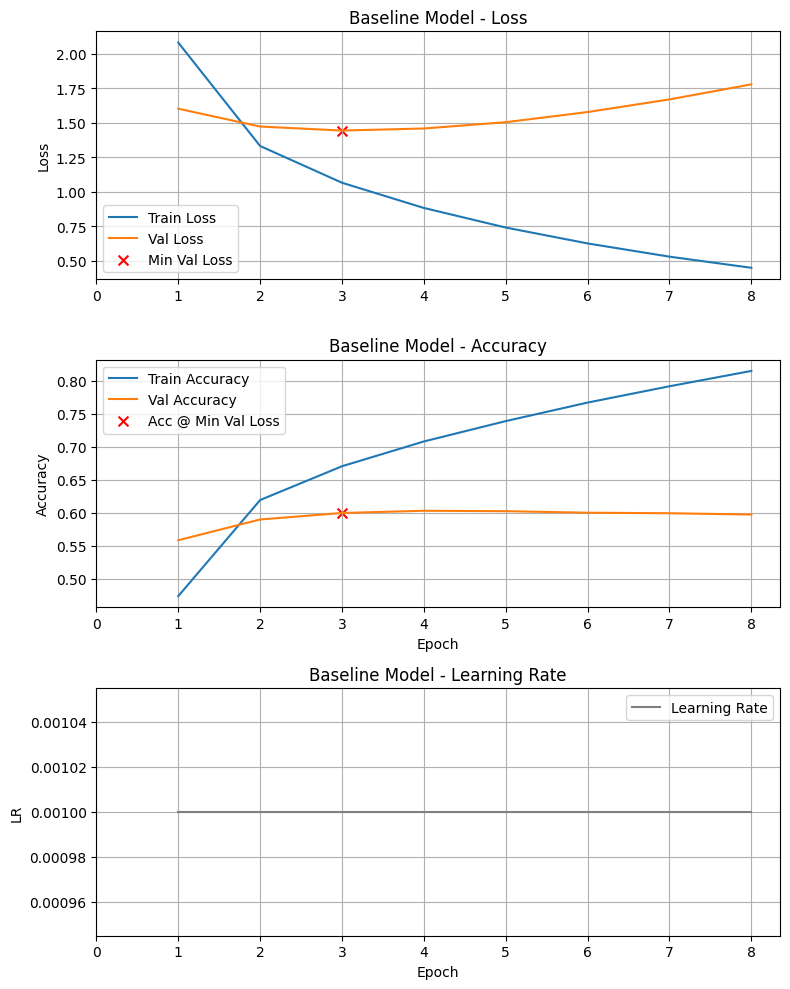

Final Training Loss:            0.4491
Final Training Accuracy:        0.8145
Final Validation Loss:          1.7774
Final Validation Accuracy:      0.5972
Minimum Validation Loss:        1.4428 (Epoch 3)
Validation Accuracy @ Min Loss: 0.5996

--- Validation Set ---

Baseline Model (Val)
  Accuracy:    0.5996
  Macro F1:    0.5349
  Weighted F1: 0.6165
  Loss:        1.4428

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.342     0.554     0.423       388
BUSINESS & FINANCES      0.499     0.589     0.540       764
             COMEDY      0.473     0.484     0.479       516
              CRIME      0.430     0.662     0.521       340
            DIVORCE      0.654     0.728     0.689       342
          EDUCATION      0.328     0.544     0.409       215
      ENTERTAINMENT      0.728     0.521     0.607      1605
        ENVIRONMENT      0.429     0.546     0.480       394
              FIFTY      0.136     0.321     0.1

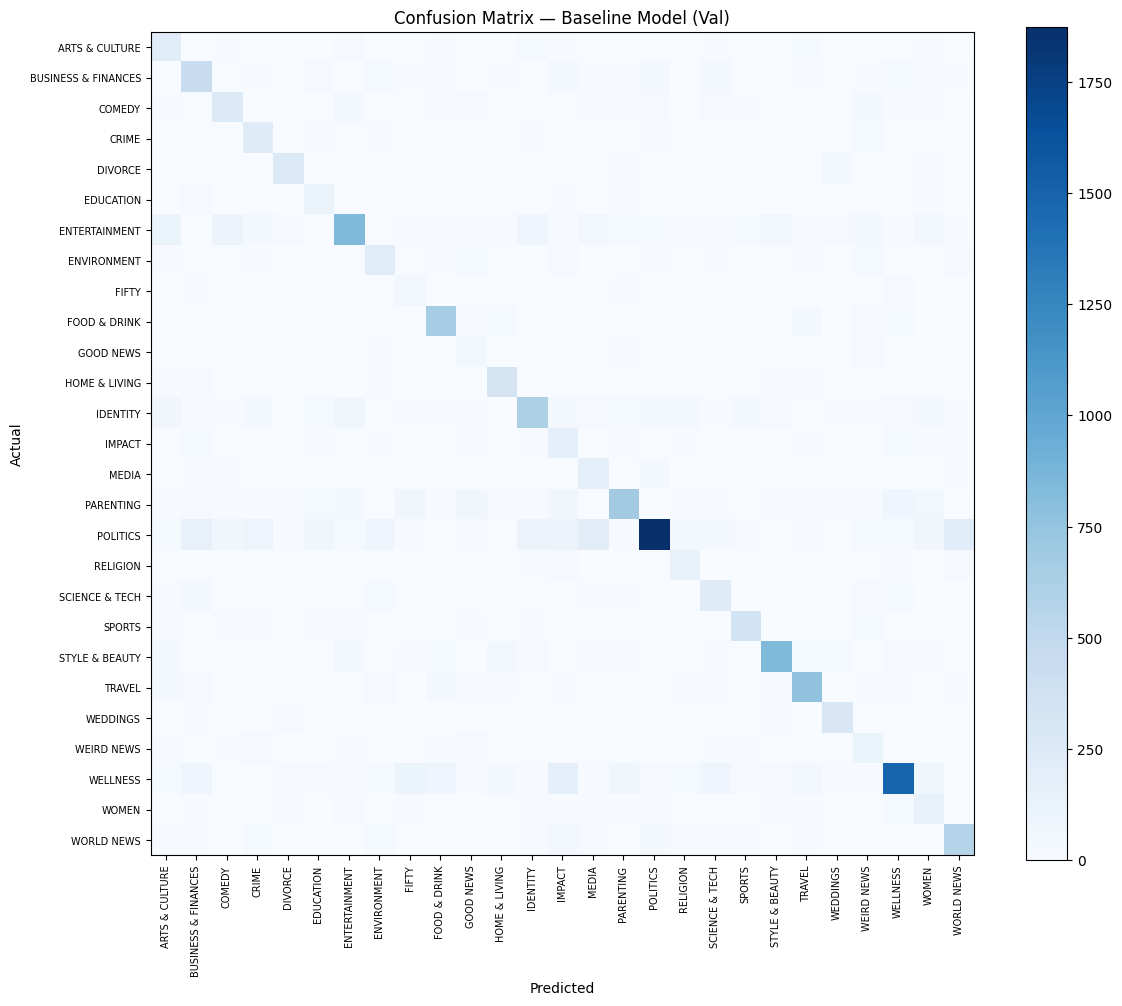


--- Test Set ---

Baseline Model (Test)
  Accuracy:    0.5981
  Macro F1:    0.5336
  Weighted F1: 0.6150
  Loss:        1.4548

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.343     0.559     0.425       388
BUSINESS & FINANCES      0.464     0.558     0.506       764
             COMEDY      0.465     0.479     0.472       516
              CRIME      0.432     0.668     0.525       340
            DIVORCE      0.705     0.763     0.733       342
          EDUCATION      0.361     0.609     0.453       215
      ENTERTAINMENT      0.732     0.511     0.602      1606
        ENVIRONMENT      0.400     0.546     0.461       394
              FIFTY      0.116     0.271     0.162       140
       FOOD & DRINK      0.719     0.770     0.744       832
          GOOD NEWS      0.191     0.393     0.257       140
      HOME & LIVING      0.634     0.779     0.699       416
           IDENTITY      0.634     0.522     0.572   

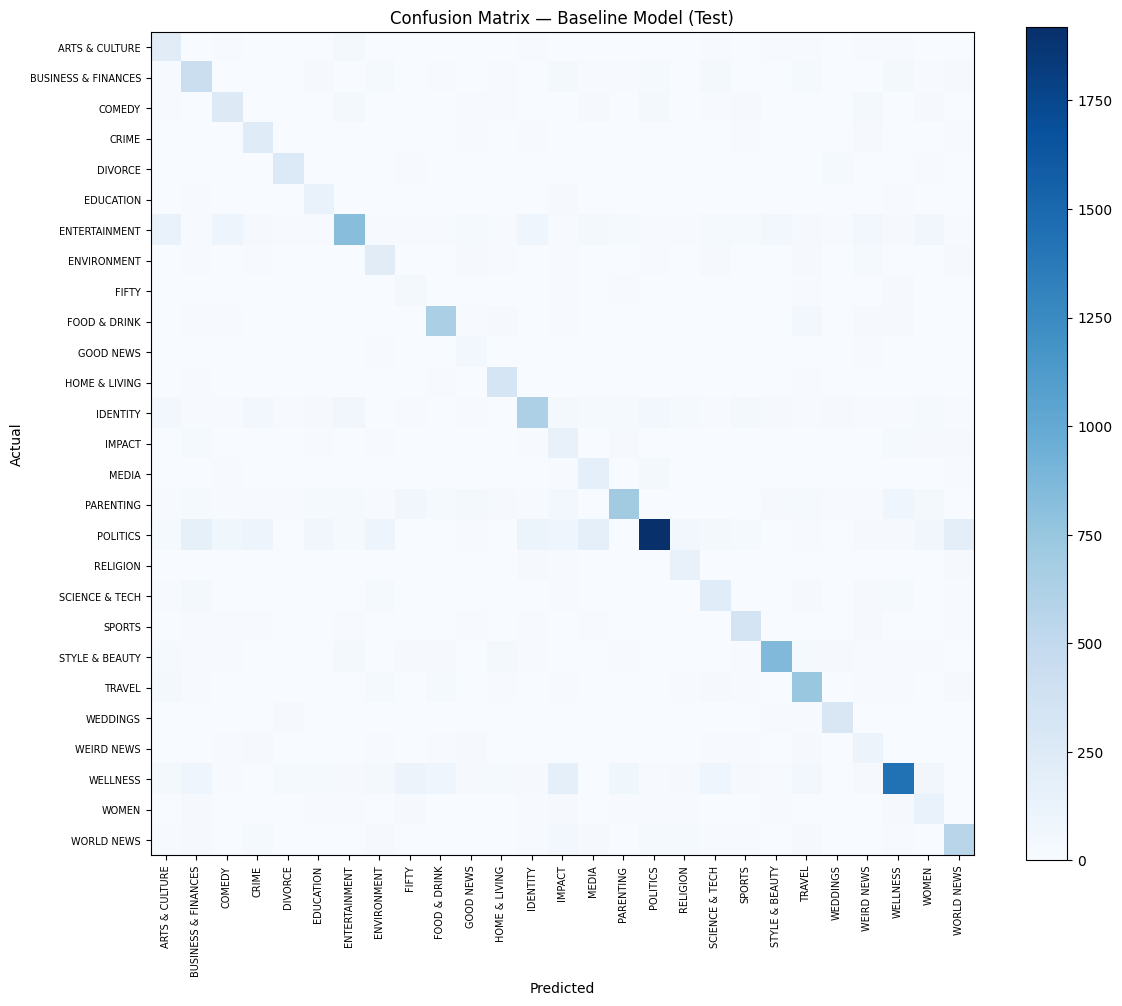


Parameters:    1,285,915
Epochs trained: 8
Training time:  00:02:18


In [38]:
baseline_results = train_and_test(
    model=baseline_model,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    title="Baseline Model",
    epochs=30,
    lr_schedule=1e-3,
    class_weight=class_weight_dict,
    patience=5,
)

### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**

Our baseline is a shallow Sequential model designed to be intentionally simple so it can serve as a lower-bound reference for the more complex architectures in Problems 3 and 4. The pipeline is: `Input(shape=(1,), dtype=tf.string)` → `TextVectorization` (20k vocab, sequence length 64) → `Embedding(20000, 64, mask_zero=True)` → `GlobalAveragePooling1D` → `Dense(64, relu)` → `Dense(27, softmax)`. The entire model has ~1.29M trainable parameters. We chose `GlobalAveragePooling1D` over an RNN/LSTM because it collapses the sequence into a fixed-length vector with minimal computation, which is appropriate for a baseline that prioritizes speed and simplicity over capturing word-order dependencies. The 64-dimensional embedding and hidden layer keep the model lightweight while still giving the network enough capacity to learn basic category-level word associations. No dropout or explicit regularization is applied — we deliberately omitted these so that any improvements from regularization in later experiments would be clearly attributable to those changes.



2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**

Training was run with `Adam(lr=1e-3)`, `batch_size=64`, `EarlyStopping(patience=5)`, and `class_weight` to address the imbalance we identified in Milestone 1. The model trained for 8 epochs before early stopping kicked in, restoring weights from the best epoch (epoch 3). Looking at the curves, training loss dropped steadily from ~2.3 down to ~0.45 and training accuracy climbed to ~0.81, but validation loss bottomed out at 1.4428 by epoch 3 and then started rising — a clear sign of overfitting. Validation accuracy plateaued around 0.60 and barely budged after epoch 3. The widening gap between training and validation loss (0.45 vs 1.78 by epoch 8) confirms the model was memorizing training examples rather than learning generalizable patterns. This is expected for a model with no regularization, and it motivates adding dropout or switching to a more expressive architecture in Problem 3.



  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**

On the validation set the baseline achieved accuracy of 0.5996, macro F1 of 0.5349, and weighted F1 of 0.6165. Test metrics are nearly identical — accuracy 0.5981, macro F1 0.5336, weighted F1 0.6150 — which is reassuring since it means the model isn't overfitting to the validation split specifically. Per-class F1 varies wildly: well-defined lifestyle categories like STYLE & BEAUTY (0.77), FOOD & DRINK (0.75), TRAVEL (0.74), and WEDDINGS (0.73) score well because their vocabulary is distinctive. On the other hand, small or semantically ambiguous categories like FIFTY (0.16), GOOD NEWS (0.26), IMPACT (0.27), and WOMEN (0.31) are essentially getting crushed. This tells us the dataset is genuinely difficult — 27 categories is a large label space, many categories overlap in vocabulary (e.g., IMPACT vs GOOD NEWS vs WORLD NEWS), and the class imbalance we flagged in Milestone 1 means minority classes have very few training examples for the model to learn from. A ~60% accuracy and ~0.53 macro F1 give us a concrete lower bound to improve on.



  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**

The baseline has three main limitations: (1) **No regularization** — training/validation loss diverge quickly, so the model overfits within a few epochs. Adding dropout after the pooling or dense layers should help. (2) **No sequence modeling** — `GlobalAveragePooling1D` treats the input as a bag of words and throws away all word-order information, which means it can't learn phrase-level patterns like "supreme court" or "climate change" that are critical for distinguishing categories like POLITICS from WORLD NEWS. A Bidirectional LSTM or Conv1D would address this. (3) **Small capacity** — 64-dimensional embeddings and a single 64-unit hidden layer limit the model's ability to separate 27 categories with overlapping vocabularies. In Problem 3 we plan to try a BiLSTM-based architecture with larger embeddings, SpatialDropout1D for regularization, and ReduceLROnPlateau to fine-tune the learning rate schedule. If those custom changes still fall short, Problem 4 will leverage a pretrained transformer (e.g., DistilBERT) that brings in external language knowledge the model can't learn from our dataset alone.



---
### 💡 Suggestion 4 — Fix Answer 3.2 Progression Narrative

**Issue:** Answer 3.2 states:
> *'BiLSTM macro F1 from 0.538 to 0.548'*

This implies the BiLSTM improves directly over the Dropout baseline (0.538), skipping the Baseline (0.534). The actual progression from actual test outputs is:

| Model | Test Macro F1 |
|-------|---------------|
| Baseline | **0.5336** |
| Baseline + Dropout | **0.5383** (+0.5 pp) |
| BiLSTM | **0.5481** (+1.0 pp from Dropout) |
| BiLSTM 40k vocab | **0.5488** (~0 pp) |
| BiLSTM 256d | **0.5551** (+0.6 pp) |
| BiLSTM + ReduceLR | **0.5573** (+0.2 pp) |
| BiLSTM + Attention | **0.5745** (+1.7 pp) ← best custom |

Cumulative gain: **+4.1 pp macro F1** from baseline to best custom model. Updating Answer 3.2 with this table makes the progression clearer and fully accurate.


## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

In [45]:
# Your code here; add as many cells as you need but make it clear what the structure is.

EMBED_DIM = 64

baseline_model_dropout = models.Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM, mask_zero=True),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

baseline_model_dropout.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_6            │ (None, 64)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 64, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 27)             │         1,755 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,285,915 (4.91 MB)

 Trainable params: 1,285,915 (4.91 MB)

 Non-trainable params: 0 (0.00 B)


  Baseline Model with Dropout(0.3)
Epoch 1/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.4359 - loss: 2.2326 - val_accuracy: 0.5723 - val_loss: 1.6217
Epoch 2/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5880 - loss: 1.4884 - val_accuracy: 0.5950 - val_loss: 1.4749
Epoch 3/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.6302 - loss: 1.2388 - val_accuracy: 0.6018 - val_loss: 1.4444
Epoch 4/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.6576 - loss: 1.0860 - val_accuracy: 0.6049 - val_loss: 1.4308
Epoch 5/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.6761 - loss: 0.9676 - val_accuracy: 0.6047 - val_loss: 1.4487
Epoch 6/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.6926 - loss: 0.8722 - val_accuracy: 0.6069 - val_loss: 1.4712
Epoch 7/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.7062 - loss: 0.7946 - val_accuracy: 0.6053 - val_loss: 1.5064
Epoch 8/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 17s 7

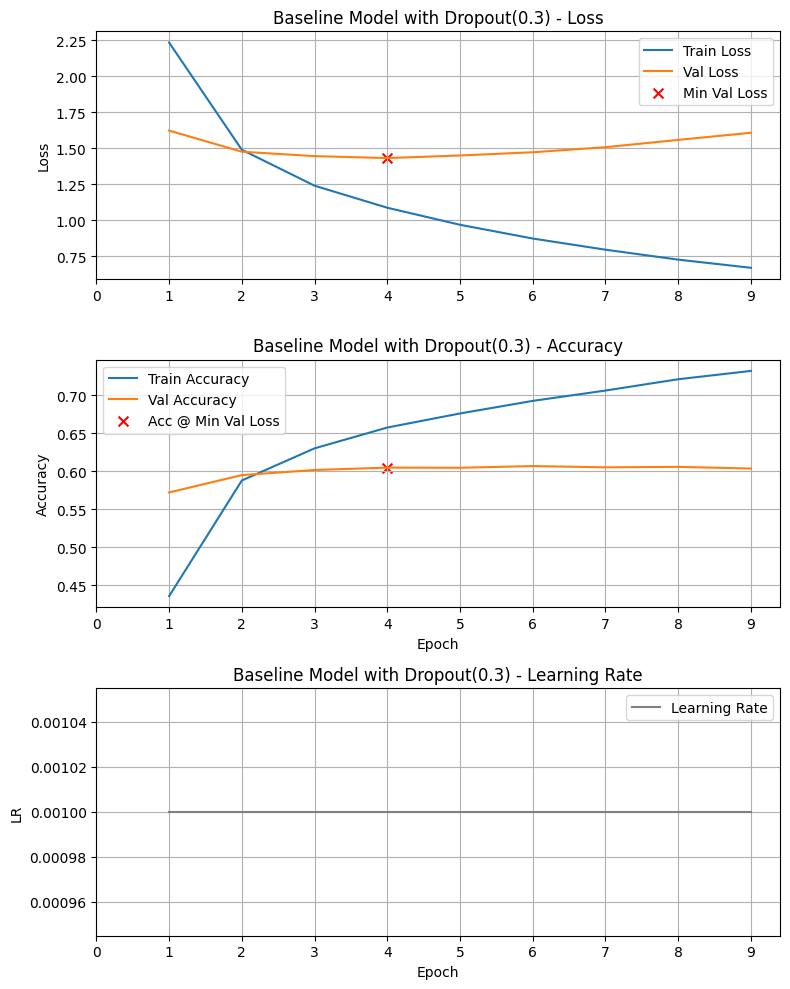

Final Training Loss:            0.6690
Final Training Accuracy:        0.7320
Final Validation Loss:          1.6066
Final Validation Accuracy:      0.6037
Minimum Validation Loss:        1.4308 (Epoch 4)
Validation Accuracy @ Min Loss: 0.6049

--- Validation Set ---

Baseline Model with Dropout(0.3) (Val)
  Accuracy:    0.6049
  Macro F1:    0.5380
  Weighted F1: 0.6200
  Loss:        1.4308

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.391     0.534     0.451       388
BUSINESS & FINANCES      0.509     0.555     0.531       764
             COMEDY      0.463     0.494     0.478       516
              CRIME      0.442     0.618     0.515       340
            DIVORCE      0.670     0.731     0.699       342
          EDUCATION      0.339     0.563     0.423       215
      ENTERTAINMENT      0.727     0.522     0.608      1605
        ENVIRONMENT      0.416     0.579     0.484       394
              FIFTY      0.141

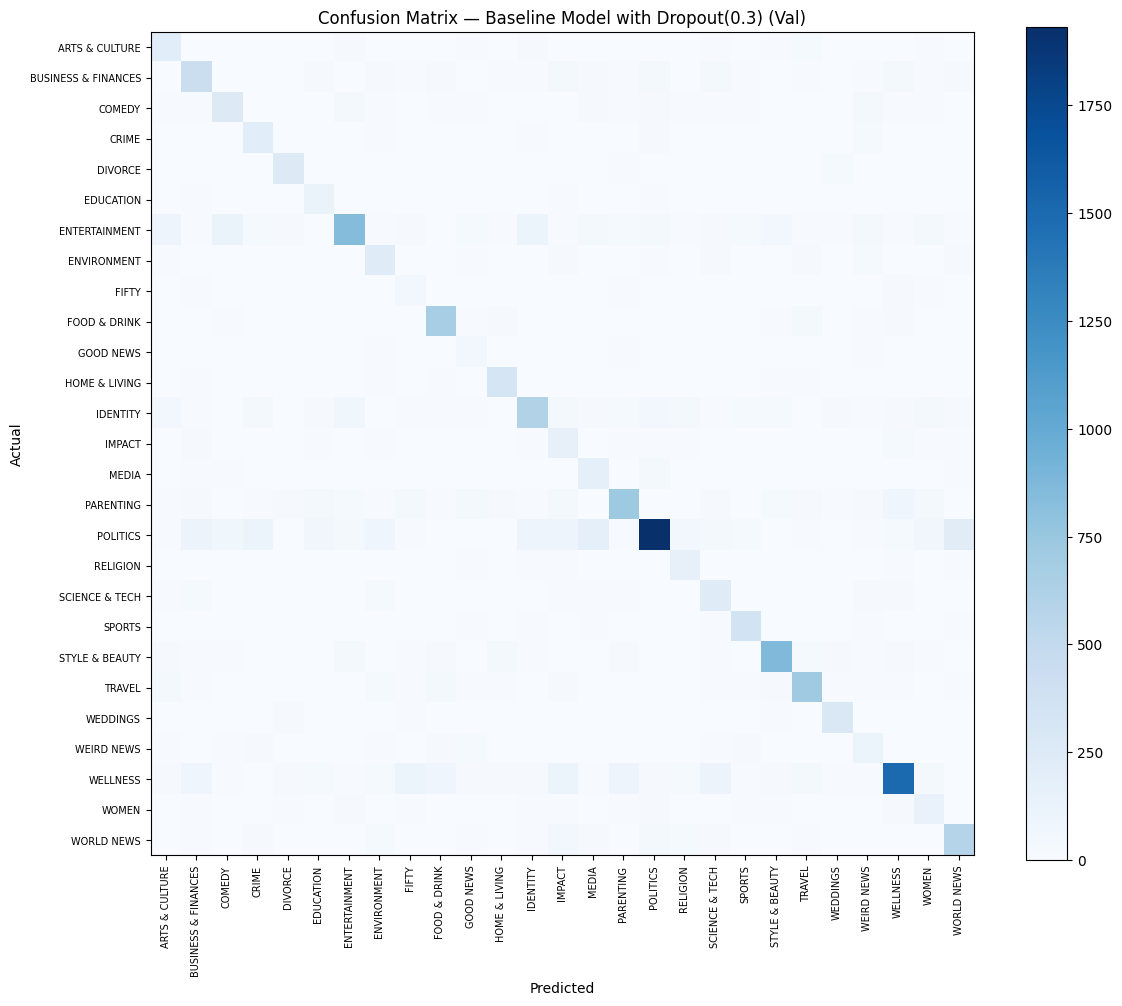


--- Test Set ---

Baseline Model with Dropout(0.3) (Test)
  Accuracy:    0.6031
  Macro F1:    0.5383
  Weighted F1: 0.6190
  Loss:        1.4477

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.379     0.552     0.450       388
BUSINESS & FINANCES      0.498     0.539     0.518       764
             COMEDY      0.474     0.484     0.479       516
              CRIME      0.430     0.647     0.516       340
            DIVORCE      0.720     0.760     0.740       342
          EDUCATION      0.363     0.605     0.454       215
      ENTERTAINMENT      0.694     0.514     0.590      1606
        ENVIRONMENT      0.408     0.556     0.470       394
              FIFTY      0.113     0.307     0.165       140
       FOOD & DRINK      0.705     0.786     0.743       832
          GOOD NEWS      0.205     0.436     0.279       140
      HOME & LIVING      0.656     0.760     0.704       416
           IDENTITY      0.607     

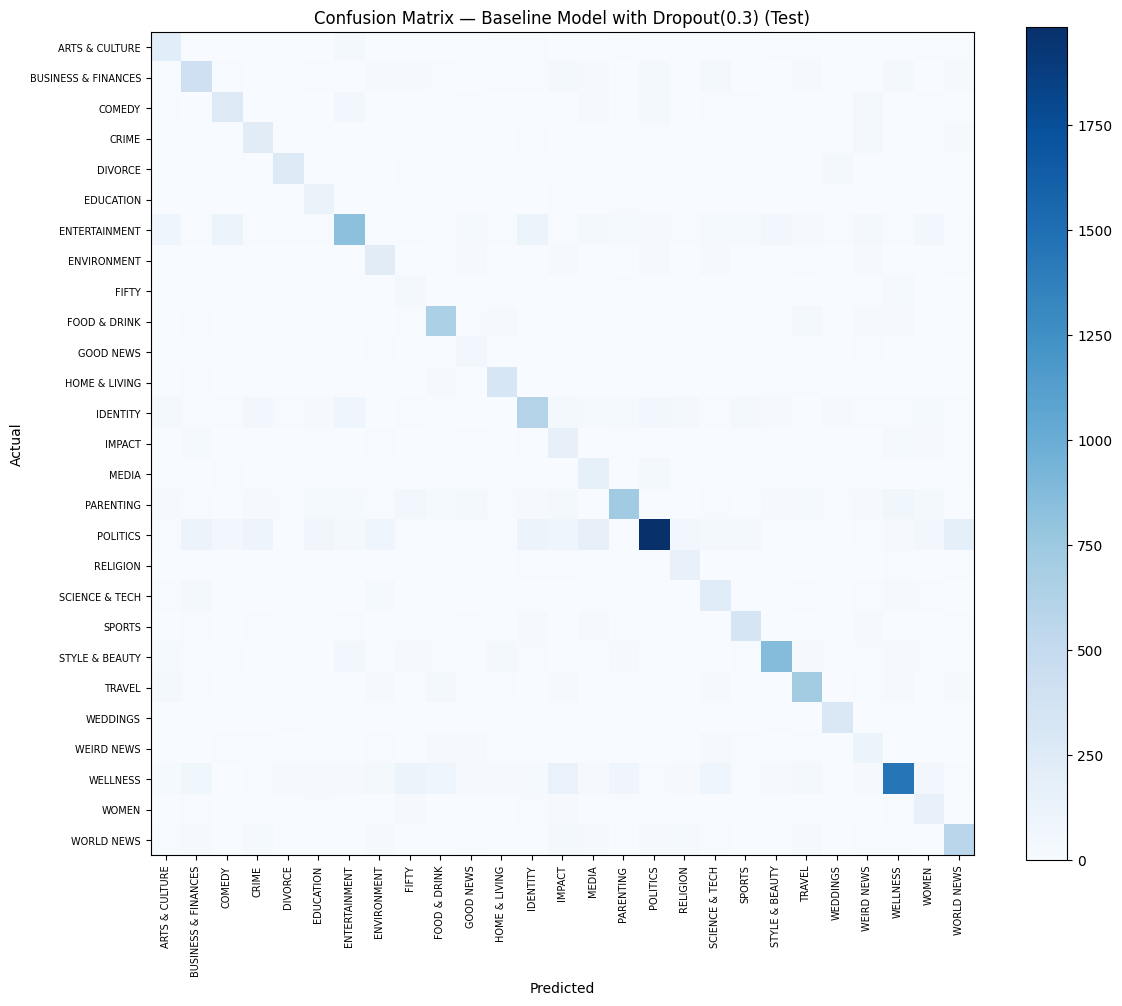


Parameters:    1,285,915
Epochs trained: 9
Training time:  00:02:37


In [47]:
baseline_dropout_results = train_and_test(
    model=baseline_model_dropout,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    title="Baseline Model with Dropout(0.3)",
    epochs=30,
    lr_schedule=1e-3,
    class_weight=class_weight_dict,
    patience=5,
)

In [48]:
model_bilstm = models.Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=128, mask_zero=True),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model_bilstm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_6            │ (None, 64)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_6 (Embedding)         │ (None, 64, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 64, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 27)             │         1,755 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,668,827 (10.18 MB)

 Trainable params: 2,668,827 (10.18 MB)

 Non-trainable params: 0 (0.00 B)


  BiLSTM Model
Epoch 1/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.3939 - loss: 2.2104 - val_accuracy: 0.5652 - val_loss: 1.5898
Epoch 2/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.5799 - loss: 1.5012 - val_accuracy: 0.6071 - val_loss: 1.4268
Epoch 3/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.6327 - loss: 1.2461 - val_accuracy: 0.6176 - val_loss: 1.3864
Epoch 4/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.6668 - loss: 1.0739 - val_accuracy: 0.6202 - val_loss: 1.3965
Epoch 5/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.6907 - loss: 0.9418 - val_accuracy: 0.6205 - val_loss: 1.4362
Epoch 6/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.7141 - loss: 0.8239 - val_accuracy: 0.6211 - val_loss: 1.4870
Epoch 7/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.7341 - loss: 0.7241 - val_accuracy: 0.6230 - val_loss: 1.5493
Epoch 8/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - ac

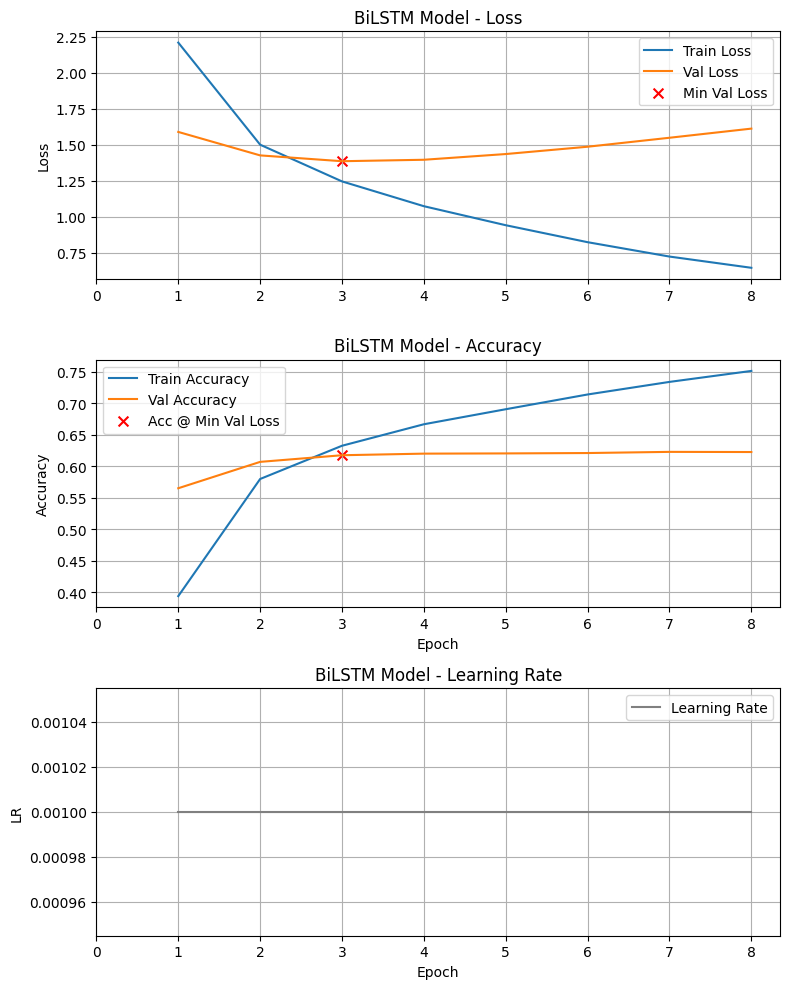

Final Training Loss:            0.6461
Final Training Accuracy:        0.7515
Final Validation Loss:          1.6128
Final Validation Accuracy:      0.6227
Minimum Validation Loss:        1.3864 (Epoch 3)
Validation Accuracy @ Min Loss: 0.6176

--- Validation Set ---

BiLSTM Model (Val)
  Accuracy:    0.6176
  Macro F1:    0.5499
  Weighted F1: 0.6312
  Loss:        1.3864

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.380     0.590     0.463       388
BUSINESS & FINANCES      0.590     0.500     0.541       764
             COMEDY      0.529     0.494     0.511       516
              CRIME      0.424     0.653     0.514       340
            DIVORCE      0.797     0.725     0.760       342
          EDUCATION      0.357     0.623     0.454       215
      ENTERTAINMENT      0.727     0.538     0.619      1605
        ENVIRONMENT      0.446     0.561     0.497       394
              FIFTY      0.175     0.393     0.242

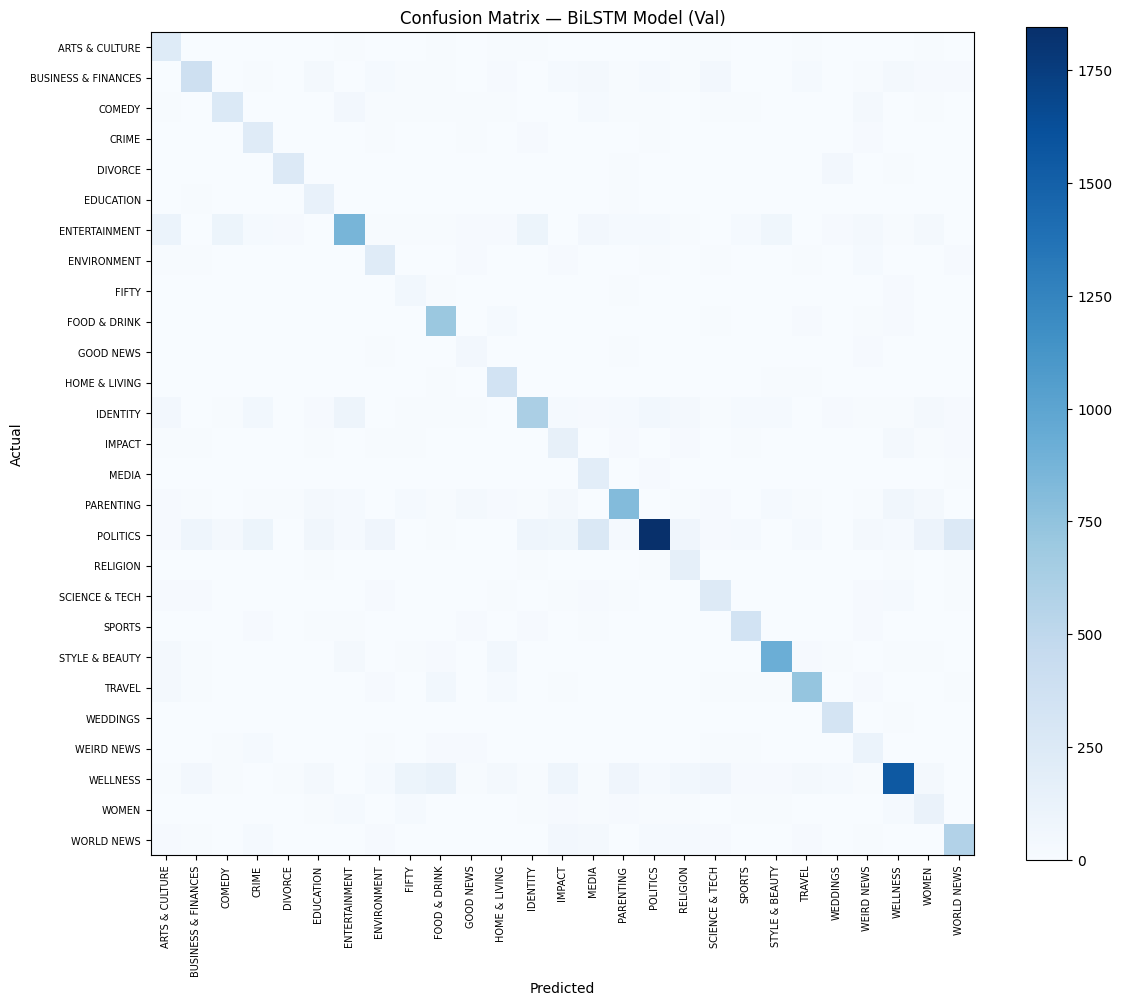


--- Test Set ---

BiLSTM Model (Test)
  Accuracy:    0.6144
  Macro F1:    0.5481
  Weighted F1: 0.6276
  Loss:        1.3933

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.375     0.613     0.466       388
BUSINESS & FINANCES      0.559     0.490     0.522       764
             COMEDY      0.503     0.473     0.488       516
              CRIME      0.434     0.697     0.535       340
            DIVORCE      0.823     0.734     0.776       342
          EDUCATION      0.363     0.628     0.460       215
      ENTERTAINMENT      0.721     0.524     0.607      1606
        ENVIRONMENT      0.454     0.525     0.487       394
              FIFTY      0.172     0.386     0.238       140
       FOOD & DRINK      0.660     0.846     0.742       832
          GOOD NEWS      0.202     0.371     0.261       140
      HOME & LIVING      0.583     0.865     0.697       416
           IDENTITY      0.658     0.509     0.574     

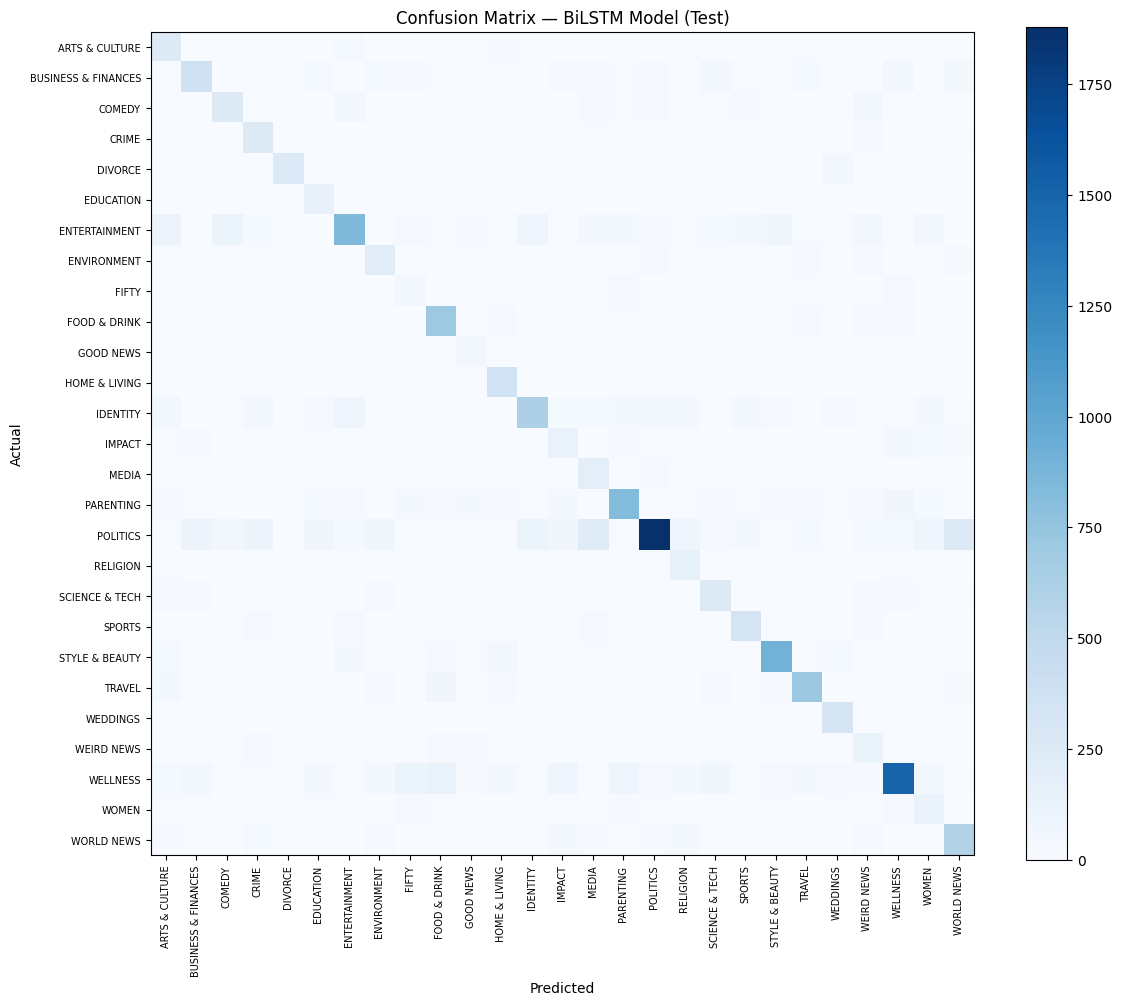


Parameters:    2,668,827
Epochs trained: 8
Training time:  00:04:45


In [49]:
bilstm_results = train_and_test(
    model=model_bilstm,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    title="BiLSTM Model",
    epochs=30,
    lr_schedule=1e-3,
    class_weight=class_weight_dict,
    patience=5,
)

In [17]:
MAX_TOKENS = 40_000 ## 40k most common tokens
MAX_LEN = 64 ## 95th percentile of text lengths

vectorize_layer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN,
)
vectorize_layer.adapt(X_train)

In [53]:
model_bilstm_increase_vocab_size = models.Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=128, mask_zero=True),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model_bilstm_increase_vocab_size.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_7            │ (None, 64)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_8 (Embedding)         │ (None, 64, 128)        │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 64, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 27)             │         1,755 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,228,827 (19.95 MB)

 Trainable params: 5,228,827 (19.95 MB)

 Non-trainable params: 0 (0.00 B)


  BiLSTM Model with Increased Vocab Size
Epoch 1/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.4118 - loss: 2.1568 - val_accuracy: 0.5638 - val_loss: 1.5645
Epoch 2/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.5963 - loss: 1.4248 - val_accuracy: 0.6153 - val_loss: 1.3897
Epoch 3/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.6579 - loss: 1.1328 - val_accuracy: 0.6173 - val_loss: 1.3947
Epoch 4/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.6991 - loss: 0.9317 - val_accuracy: 0.6214 - val_loss: 1.4144
Epoch 5/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.7345 - loss: 0.7739 - val_accuracy: 0.6301 - val_loss: 1.4794
Epoch 6/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.7653 - loss: 0.6459 - val_accuracy: 0.6322 - val_loss: 1.5642
Epoch 7/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.7898 - loss: 0.5453 - val_accuracy: 0.6358 - val_loss: 1.6653
Epoch 7: early stopping
Restoring 

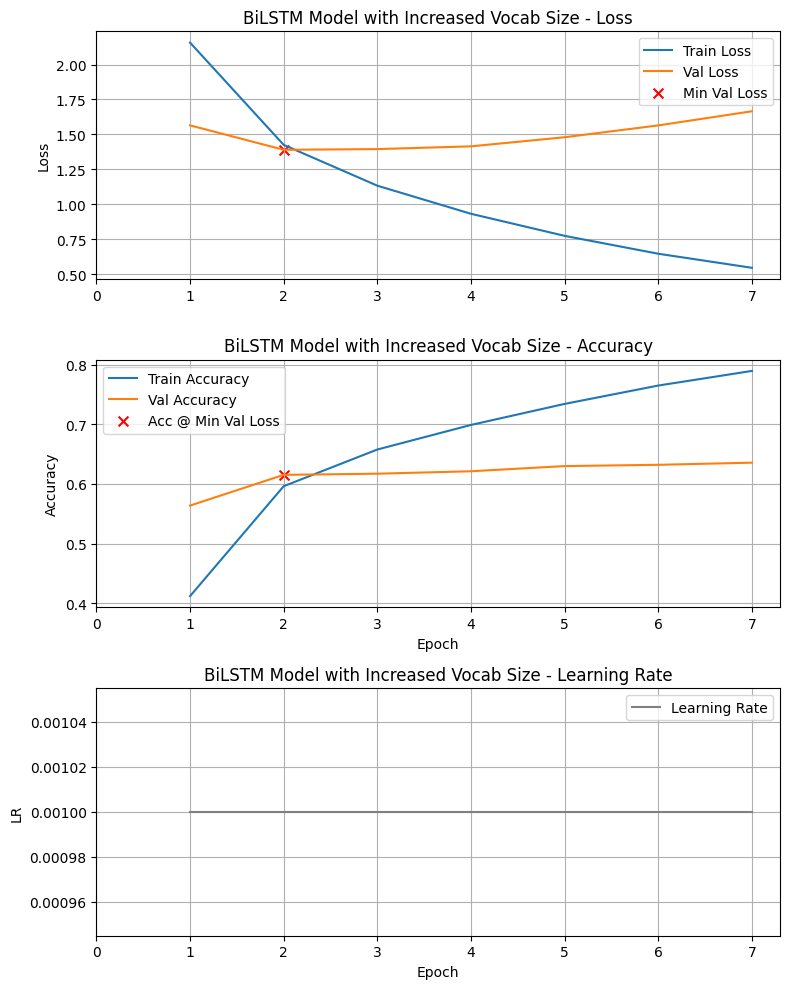

Final Training Loss:            0.5453
Final Training Accuracy:        0.7898
Final Validation Loss:          1.6653
Final Validation Accuracy:      0.6358
Minimum Validation Loss:        1.3897 (Epoch 2)
Validation Accuracy @ Min Loss: 0.6153

--- Validation Set ---

BiLSTM Model with Increased Vocab Size (Val)
  Accuracy:    0.6153
  Macro F1:    0.5499
  Weighted F1: 0.6305
  Loss:        1.3897

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.357     0.575     0.440       388
BUSINESS & FINANCES      0.480     0.546     0.511       764
             COMEDY      0.482     0.494     0.488       516
              CRIME      0.408     0.656     0.503       340
            DIVORCE      0.705     0.760     0.731       342
          EDUCATION      0.322     0.651     0.431       215
      ENTERTAINMENT      0.733     0.526     0.613      1605
        ENVIRONMENT      0.489     0.525     0.507       394
              FIFTY     

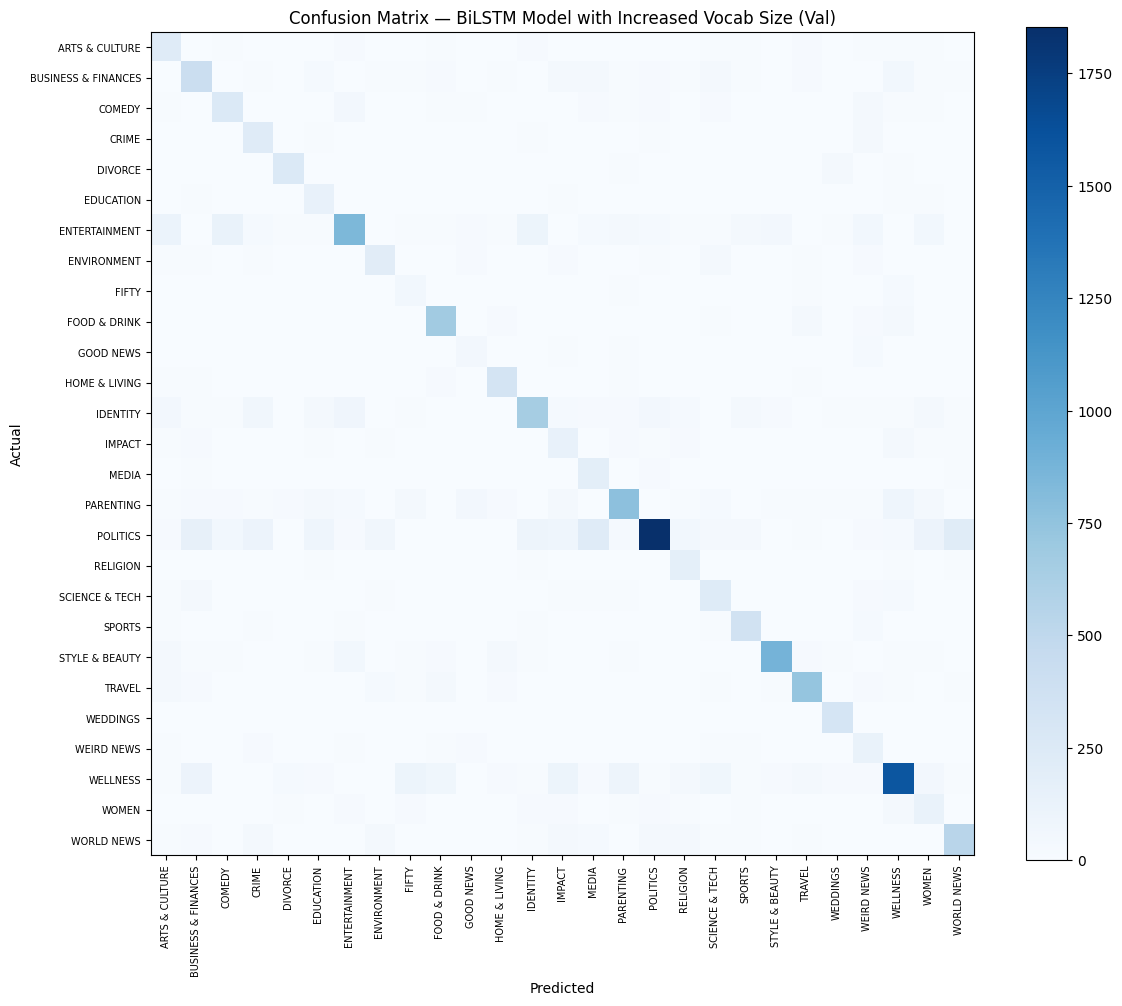


--- Test Set ---

BiLSTM Model with Increased Vocab Size (Test)
  Accuracy:    0.6139
  Macro F1:    0.5488
  Weighted F1: 0.6290
  Loss:        1.3969

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.340     0.606     0.435       388
BUSINESS & FINANCES      0.485     0.527     0.505       764
             COMEDY      0.479     0.481     0.480       516
              CRIME      0.401     0.694     0.509       340
            DIVORCE      0.729     0.769     0.748       342
          EDUCATION      0.311     0.660     0.423       215
      ENTERTAINMENT      0.719     0.498     0.588      1606
        ENVIRONMENT      0.457     0.513     0.483       394
              FIFTY      0.187     0.379     0.250       140
       FOOD & DRINK      0.741     0.827     0.781       832
          GOOD NEWS      0.220     0.357     0.272       140
      HOME & LIVING      0.704     0.808     0.753       416
           IDENTITY      0.64

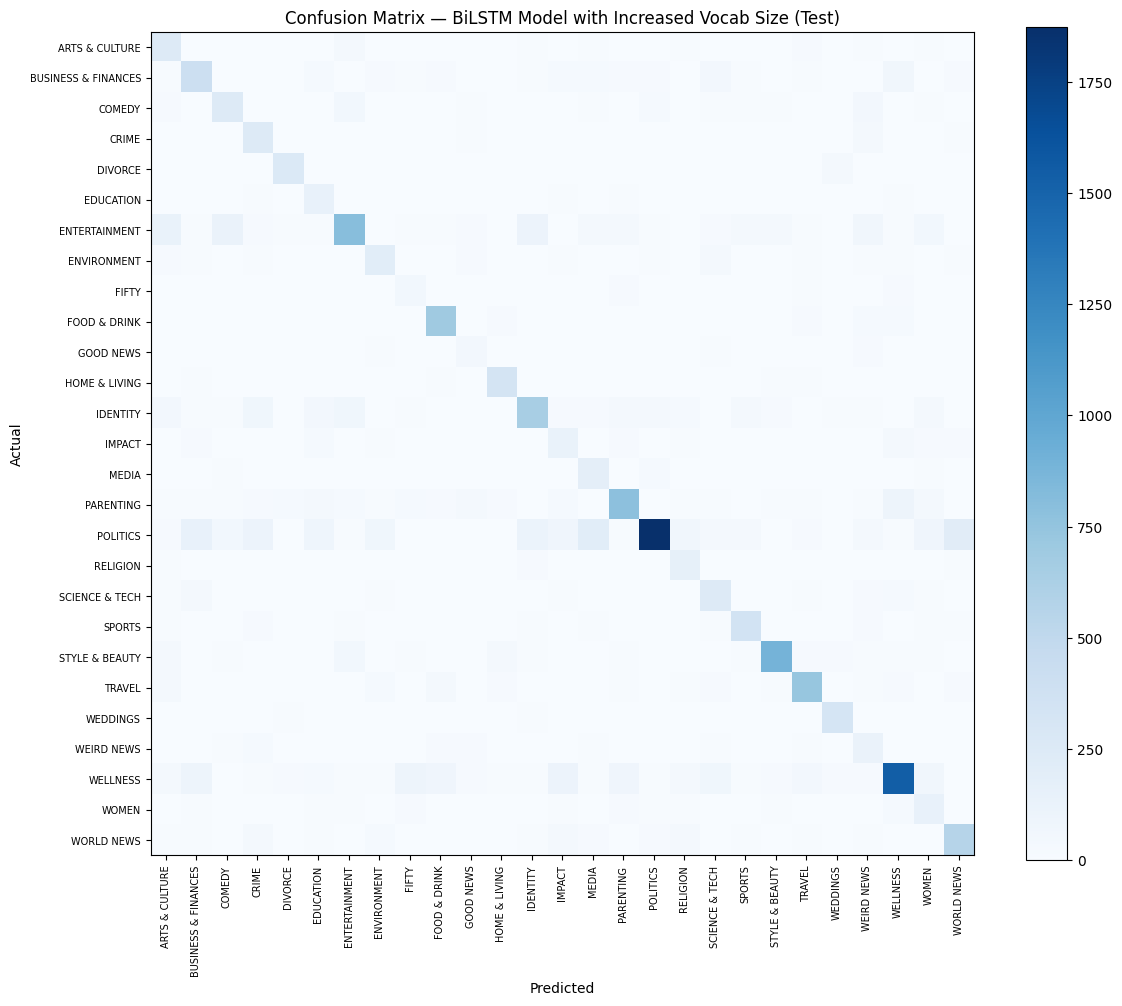


Parameters:    5,228,827
Epochs trained: 7
Training time:  00:04:30


In [54]:
bilstm_increase_vocab_size_results = train_and_test(
    model=model_bilstm_increase_vocab_size,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    title="BiLSTM Model with Increased Vocab Size",
    epochs=30,
    lr_schedule=1e-3,
    class_weight=class_weight_dict,
    patience=5,
)

In [55]:
model_bilstm_increase_vocab_size_256d = models.Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=256, mask_zero=True),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model_bilstm_increase_vocab_size_256d.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_7            │ (None, 64)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_9 (Embedding)         │ (None, 64, 256)        │    10,240,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 64, 256)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 27)             │         1,755 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,414,363 (39.73 MB)

 Trainable params: 10,414,363 (39.73 MB)

 Non-trainable params: 0 (0.00 B)


  BiLSTM Model with Increased Vocab Size & 256 Dimensions
Epoch 1/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.4164 - loss: 2.0930 - val_accuracy: 0.5918 - val_loss: 1.4868
Epoch 2/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.6109 - loss: 1.3383 - val_accuracy: 0.6189 - val_loss: 1.3721
Epoch 3/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.6839 - loss: 1.0036 - val_accuracy: 0.6247 - val_loss: 1.3969
Epoch 4/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.7378 - loss: 0.7655 - val_accuracy: 0.6298 - val_loss: 1.4688
Epoch 5/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.7782 - loss: 0.5916 - val_accuracy: 0.6324 - val_loss: 1.5890
Epoch 6/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.8111 - loss: 0.4689 - val_accuracy: 0.6311 - val_loss: 1.7523
Epoch 7/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.8386 - loss: 0.3774 - val_accuracy: 0.6322 - val_loss: 1.9300
Epoch 7: early st

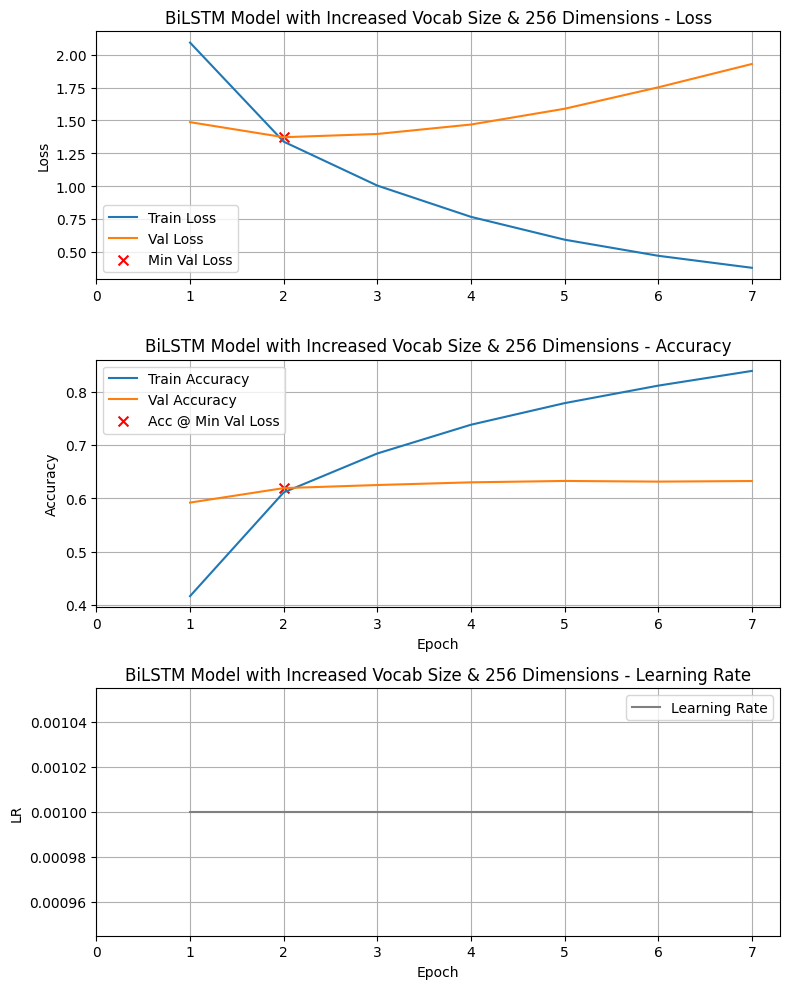

Final Training Loss:            0.3774
Final Training Accuracy:        0.8386
Final Validation Loss:          1.9300
Final Validation Accuracy:      0.6322
Minimum Validation Loss:        1.3721 (Epoch 2)
Validation Accuracy @ Min Loss: 0.6189

--- Validation Set ---

BiLSTM Model with Increased Vocab Size & 256 Dimensions (Val)
  Accuracy:    0.6189
  Macro F1:    0.5551
  Weighted F1: 0.6319
  Loss:        1.3721

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.399     0.585     0.474       388
BUSINESS & FINANCES      0.493     0.564     0.526       764
             COMEDY      0.461     0.521     0.490       516
              CRIME      0.429     0.656     0.519       340
            DIVORCE      0.752     0.737     0.744       342
          EDUCATION      0.330     0.633     0.434       215
      ENTERTAINMENT      0.725     0.550     0.626      1605
        ENVIRONMENT      0.443     0.569     0.498       394
       

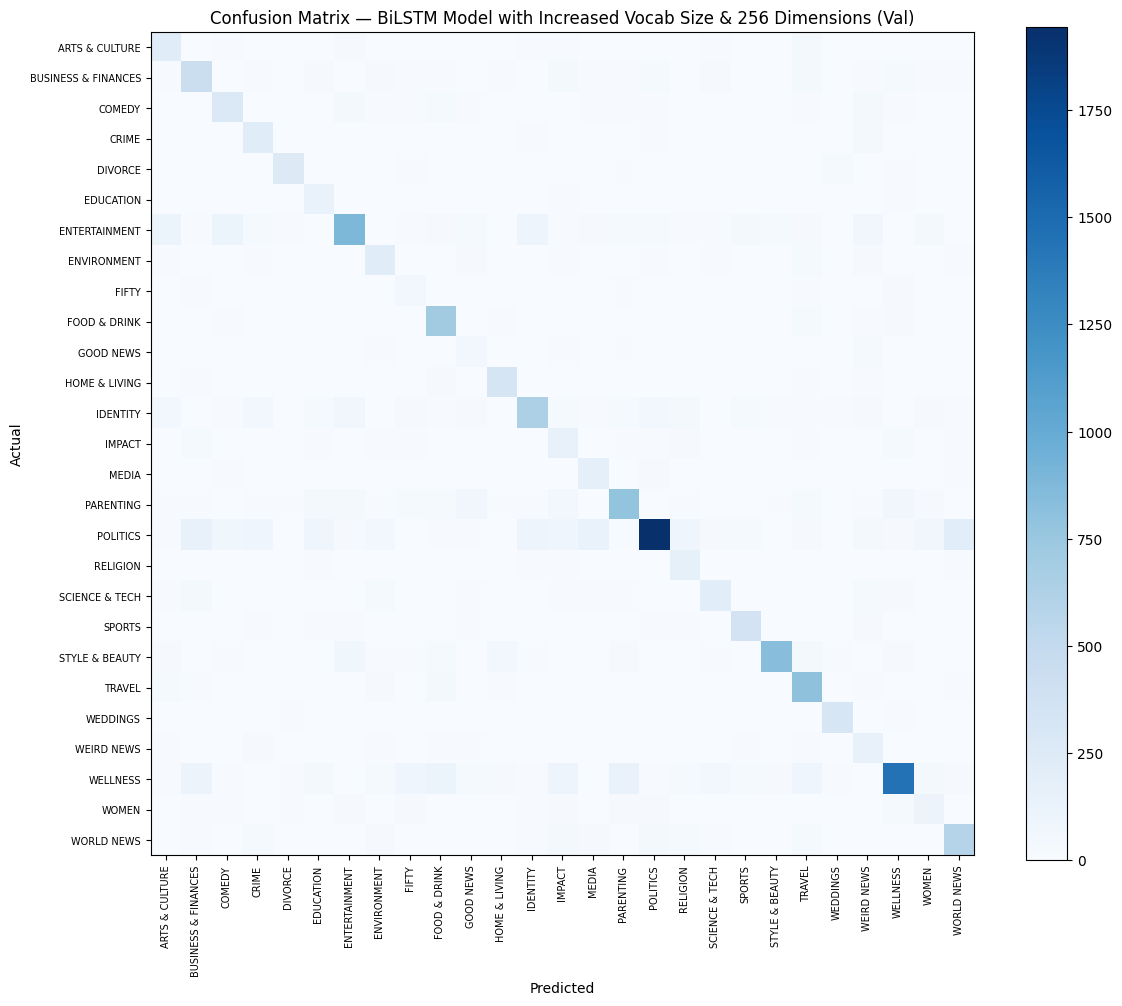


--- Test Set ---

BiLSTM Model with Increased Vocab Size & 256 Dimensions (Test)
  Accuracy:    0.6164
  Macro F1:    0.5551
  Weighted F1: 0.6296
  Loss:        1.3832

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.378     0.606     0.466       388
BUSINESS & FINANCES      0.492     0.563     0.525       764
             COMEDY      0.441     0.504     0.471       516
              CRIME      0.436     0.656     0.524       340
            DIVORCE      0.811     0.766     0.788       342
          EDUCATION      0.343     0.647     0.448       215
      ENTERTAINMENT      0.704     0.539     0.610      1606
        ENVIRONMENT      0.432     0.533     0.477       394
              FIFTY      0.173     0.364     0.234       140
       FOOD & DRINK      0.655     0.855     0.741       832
          GOOD NEWS      0.205     0.457     0.283       140
      HOME & LIVING      0.671     0.793     0.727       416
           I

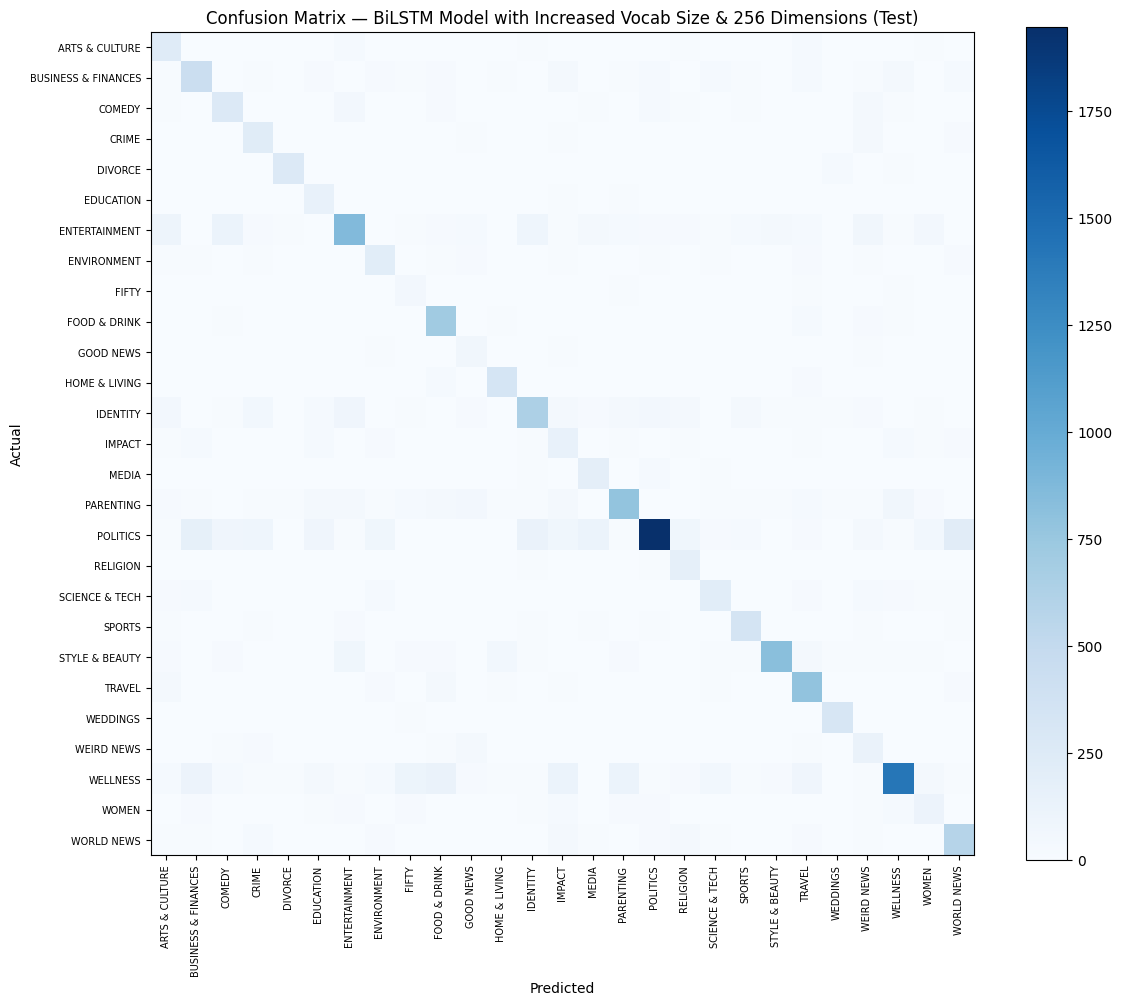


Parameters:    10,414,363
Epochs trained: 7
Training time:  00:04:43


In [56]:
bilstm_increase_vocab_size__256d_results = train_and_test(
    model=model_bilstm_increase_vocab_size_256d,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    title="BiLSTM Model with Increased Vocab Size & 256 Dimensions",
    epochs=30,
    lr_schedule=1e-3,
    class_weight=class_weight_dict,
    patience=5,
)


  BiLSTM with ReduceLR
Epoch 1/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.4250 - loss: 2.0931 - val_accuracy: 0.5726 - val_loss: 1.5175 - learning_rate: 0.0010
Epoch 2/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.6047 - loss: 1.3578 - val_accuracy: 0.6150 - val_loss: 1.3801 - learning_rate: 0.0010
Epoch 3/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.6700 - loss: 1.0608 - val_accuracy: 0.6270 - val_loss: 1.3634 - learning_rate: 0.0010
Epoch 4/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.7160 - loss: 0.8516 - val_accuracy: 0.6279 - val_loss: 1.4284 - learning_rate: 0.0010
Epoch 5/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.7517 - loss: 0.6933 - val_accuracy: 0.6329 - val_loss: 1.5116 - learning_rate: 0.0010
Epoch 6/30
2503/2505 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7751 - loss: 0.5998
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 

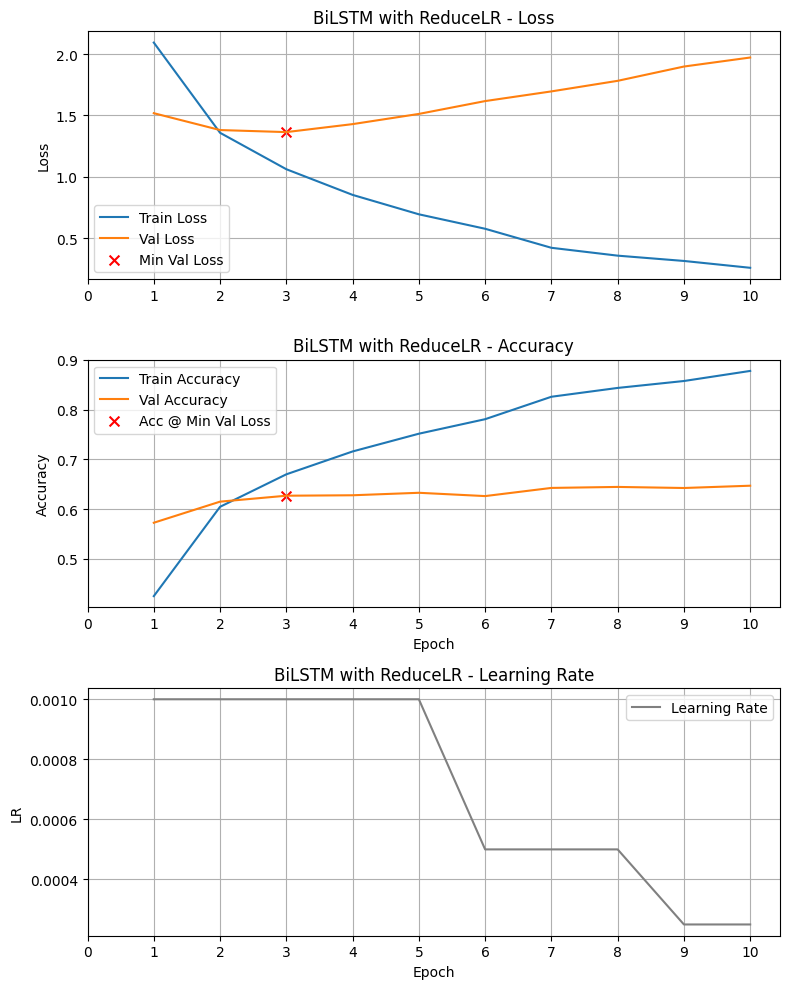

Final Training Loss:            0.2573
Final Training Accuracy:        0.8780
Final Validation Loss:          1.9714
Final Validation Accuracy:      0.6471
Minimum Validation Loss:        1.3634 (Epoch 3)
Validation Accuracy @ Min Loss: 0.6270

--- Validation Set ---

BiLSTM with ReduceLR (Val)
  Accuracy:    0.6270
  Macro F1:    0.5620
  Weighted F1: 0.6409
  Loss:        1.3634

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.403     0.580     0.476       388
BUSINESS & FINANCES      0.534     0.529     0.531       764
             COMEDY      0.456     0.527     0.489       516
              CRIME      0.430     0.635     0.513       340
            DIVORCE      0.674     0.754     0.712       342
          EDUCATION      0.372     0.586     0.455       215
      ENTERTAINMENT      0.749     0.518     0.612      1605
        ENVIRONMENT      0.453     0.581     0.509       394
              FIFTY      0.187     0.386  

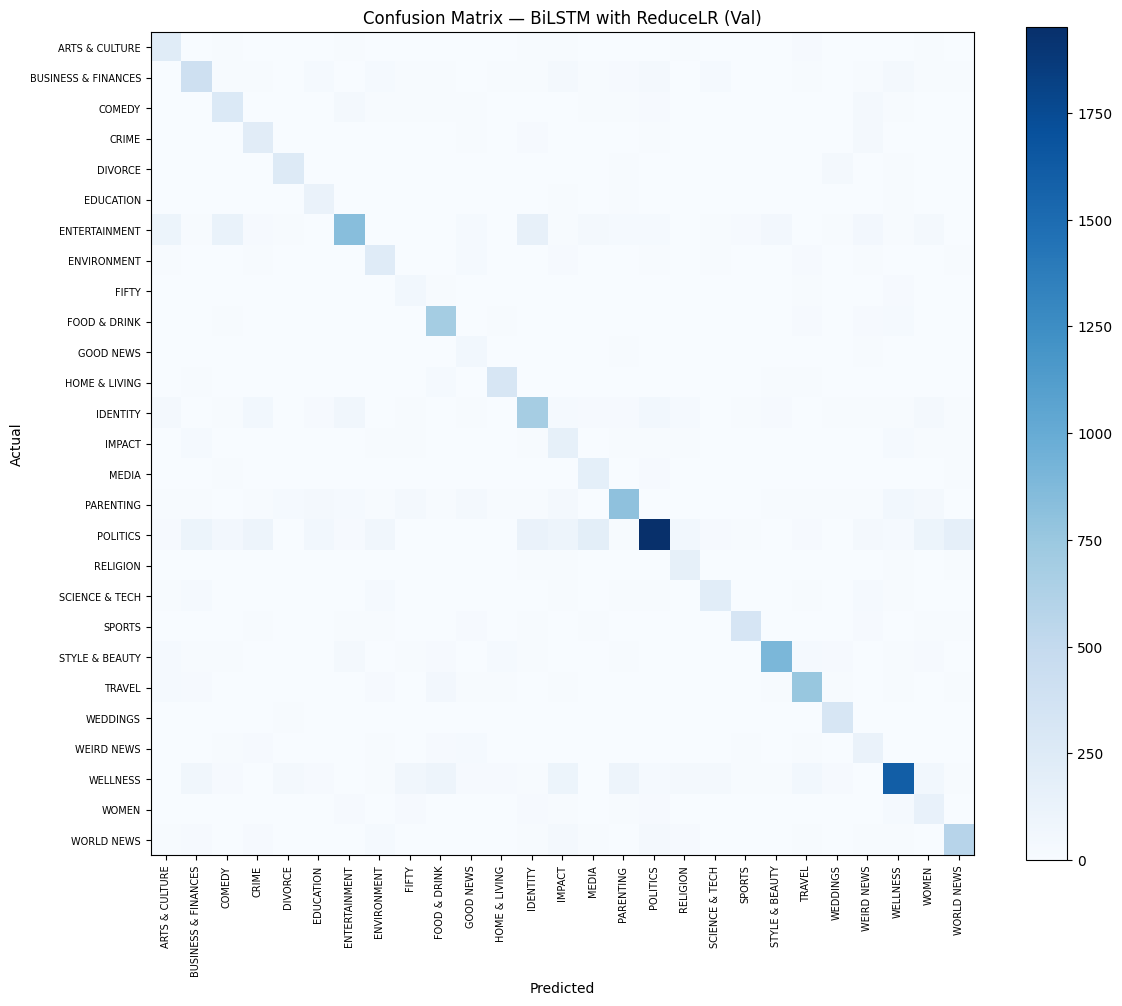


--- Test Set ---

BiLSTM with ReduceLR (Test)
  Accuracy:    0.6200
  Macro F1:    0.5573
  Weighted F1: 0.6341
  Loss:        1.3857

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.374     0.570     0.451       388
BUSINESS & FINANCES      0.513     0.518     0.516       764
             COMEDY      0.441     0.533     0.483       516
              CRIME      0.424     0.644     0.511       340
            DIVORCE      0.691     0.784     0.734       342
          EDUCATION      0.388     0.614     0.476       215
      ENTERTAINMENT      0.733     0.505     0.598      1606
        ENVIRONMENT      0.437     0.533     0.480       394
              FIFTY      0.172     0.371     0.235       140
       FOOD & DRINK      0.682     0.839     0.752       832
          GOOD NEWS      0.219     0.457     0.296       140
      HOME & LIVING      0.704     0.772     0.736       416
           IDENTITY      0.603     0.596     0.

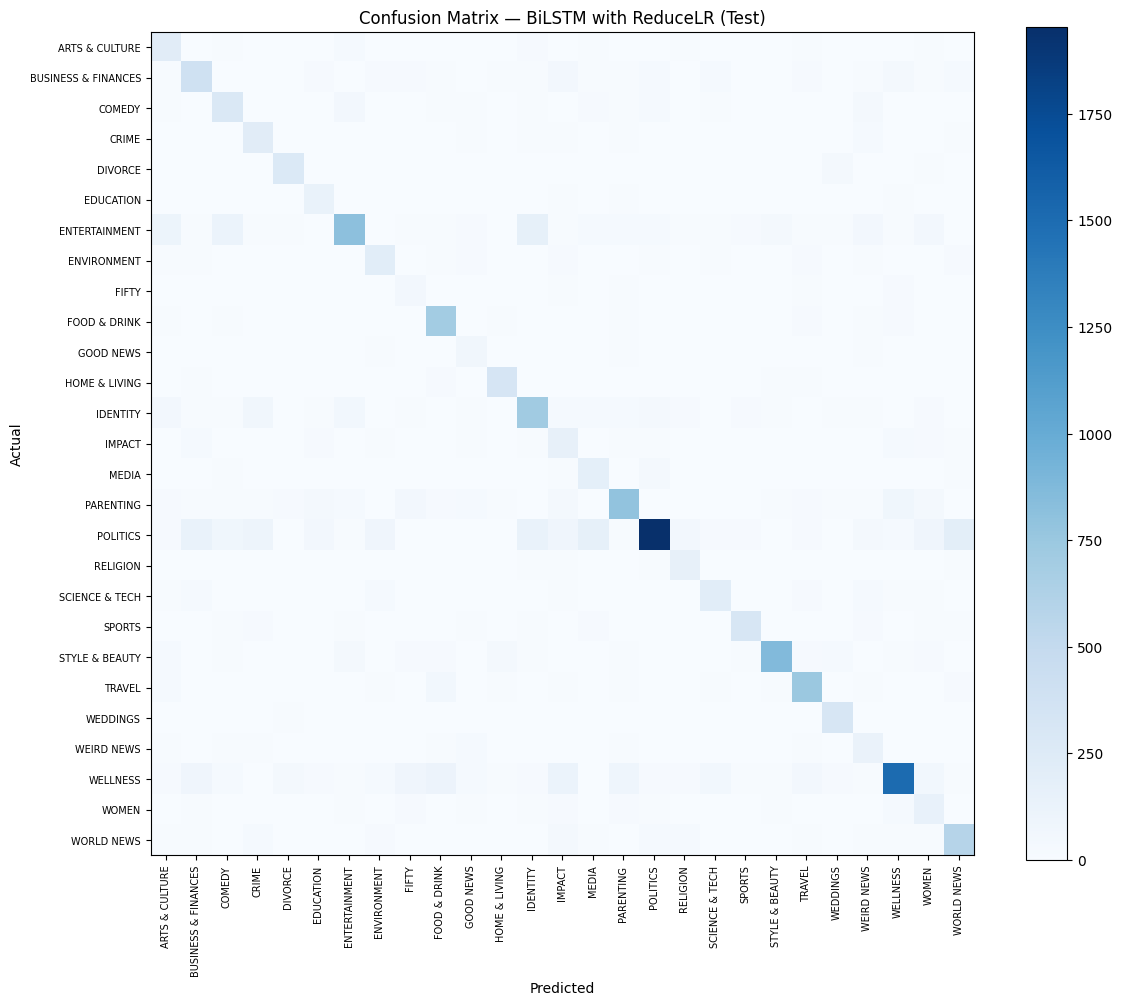


Parameters:    5,228,827
Epochs trained: 10
Training time:  00:06:21


In [57]:
model_bilstm_reduce_lr = models.Sequential([
    Input(shape=(1,), dtype=tf.string),
    vectorize_layer,
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=128, mask_zero=True),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

bilstm_reducelr_results = train_and_test(
    model=model_bilstm_reduce_lr,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    title="BiLSTM with ReduceLR",
    epochs=30,
    lr_schedule=1e-3,
    class_weight=class_weight_dict,
    patience=7,
    use_reduce_lr=True,
    reduce_lr_patience=3,
    reduce_lr_factor=0.5,
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 64)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 64, 128)        │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 64, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_2 (Attention)         │ (None, 128)            │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,239,515 (19.99 MB)

 Trainable params: 5,239,259 (19.99 MB)

 Non-trainable params: 256 (1.00 KB)


  BiLSTM with Attention
Epoch 1/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.4592 - loss: 1.9595 - val_accuracy: 0.6140 - val_loss: 1.3969 - learning_rate: 0.0010
Epoch 2/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.6462 - loss: 1.1821 - val_accuracy: 0.6294 - val_loss: 1.3129 - learning_rate: 0.0010
Epoch 3/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.7069 - loss: 0.8820 - val_accuracy: 0.6380 - val_loss: 1.3292 - learning_rate: 0.0010
Epoch 4/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.7471 - loss: 0.6853 - val_accuracy: 0.6355 - val_loss: 1.4250 - learning_rate: 0.0010
Epoch 5/30
2502/2505 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7742 - loss: 0.5730
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2505/2505 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.7803 - loss: 0.5506 - val_accuracy: 0.6294 - val_loss: 1.5613 - learning_rate: 0.0010
Epoch 6/30
2505/2505 ━━━━━━━━━━━━━━━━━━━━

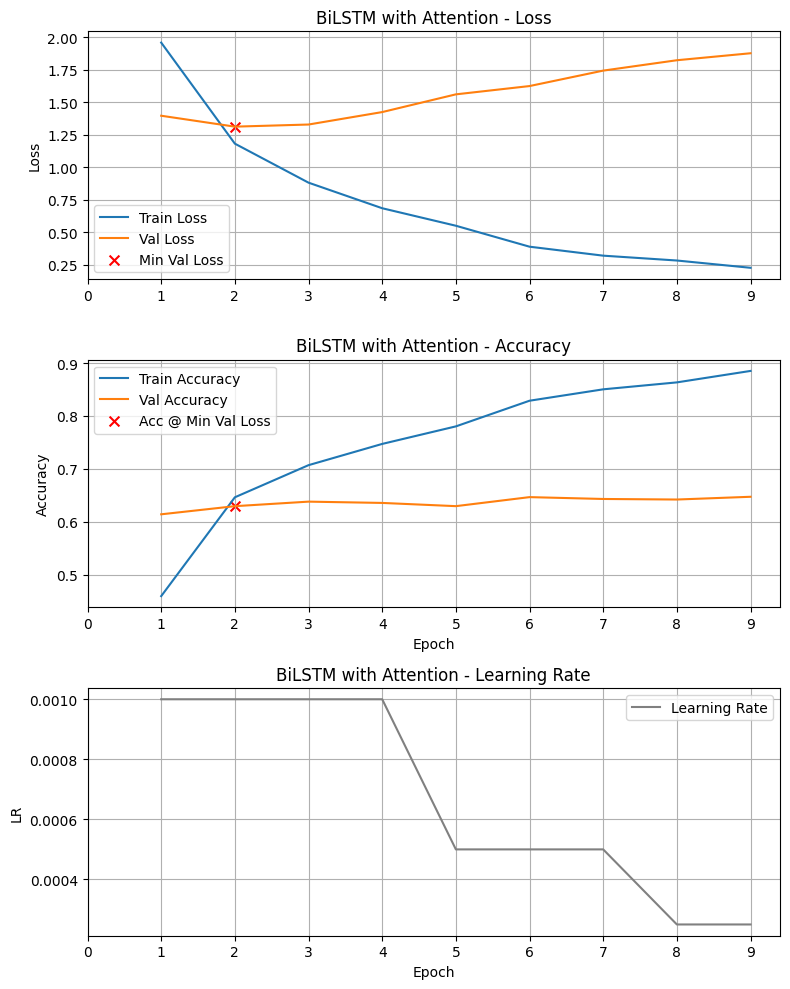

Final Training Loss:            0.2271
Final Training Accuracy:        0.8852
Final Validation Loss:          1.8775
Final Validation Accuracy:      0.6471
Minimum Validation Loss:        1.3129 (Epoch 2)
Validation Accuracy @ Min Loss: 0.6294

--- Validation Set ---

BiLSTM with Attention (Val)
  Accuracy:    0.6294
  Macro F1:    0.5674
  Weighted F1: 0.6461
  Loss:        1.3129

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.399     0.598     0.478       388
BUSINESS & FINANCES      0.578     0.546     0.561       764
             COMEDY      0.436     0.599     0.504       516
              CRIME      0.459     0.579     0.512       340
            DIVORCE      0.784     0.734     0.758       342
          EDUCATION      0.391     0.586     0.469       215
      ENTERTAINMENT      0.750     0.569     0.647      1605
        ENVIRONMENT      0.461     0.581     0.514       394
              FIFTY      0.200     0.493 

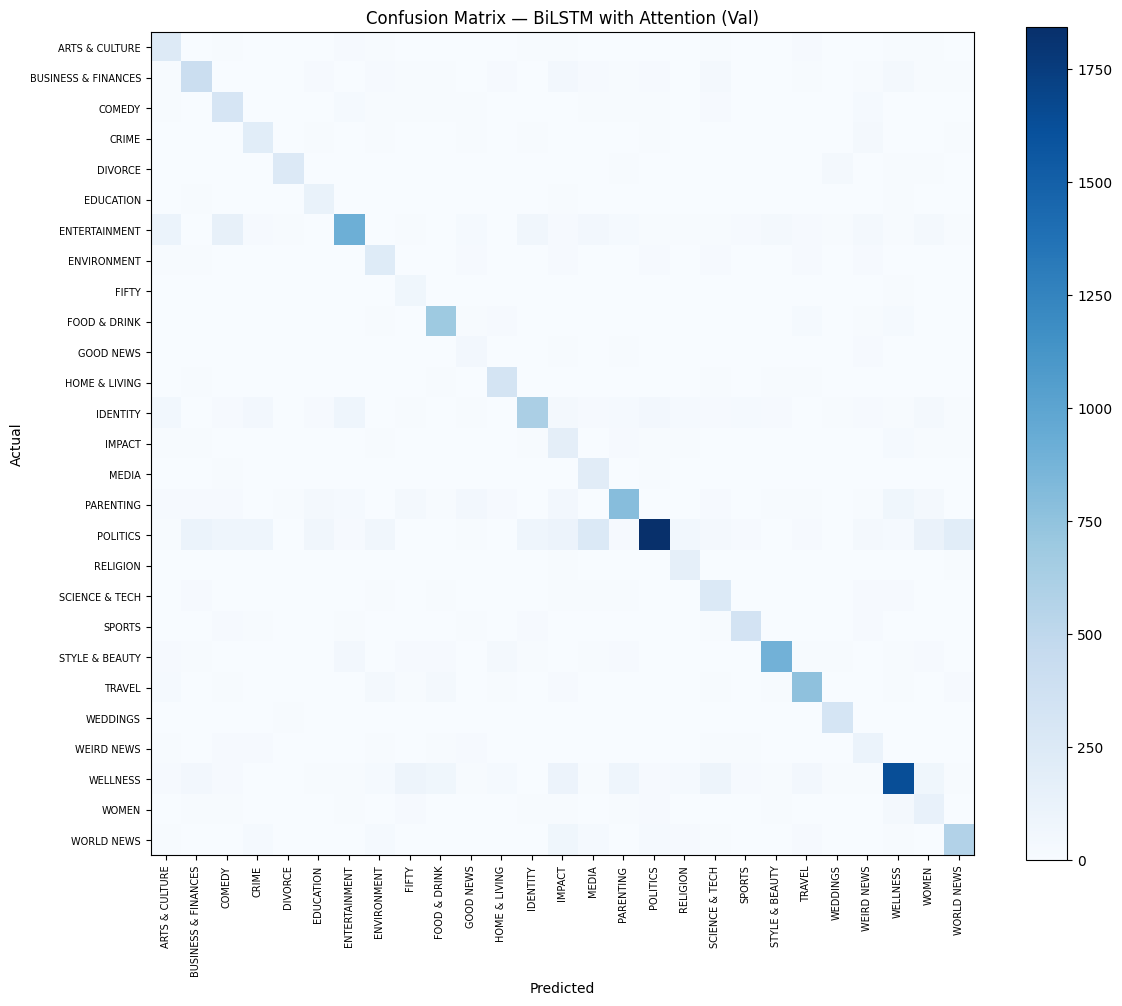


--- Test Set ---

BiLSTM with Attention (Test)
  Accuracy:    0.6330
  Macro F1:    0.5745
  Weighted F1: 0.6501
  Loss:        1.3149

Classification Report:
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.393     0.603     0.476       388
BUSINESS & FINANCES      0.574     0.562     0.568       764
             COMEDY      0.424     0.585     0.491       516
              CRIME      0.465     0.635     0.537       340
            DIVORCE      0.793     0.760     0.776       342
          EDUCATION      0.421     0.619     0.501       215
      ENTERTAINMENT      0.766     0.575     0.657      1606
        ENVIRONMENT      0.474     0.566     0.516       394
              FIFTY      0.196     0.443     0.272       140
       FOOD & DRINK      0.764     0.827     0.794       832
          GOOD NEWS      0.241     0.486     0.322       140
      HOME & LIVING      0.669     0.827     0.740       416
           IDENTITY      0.723     0.534     0

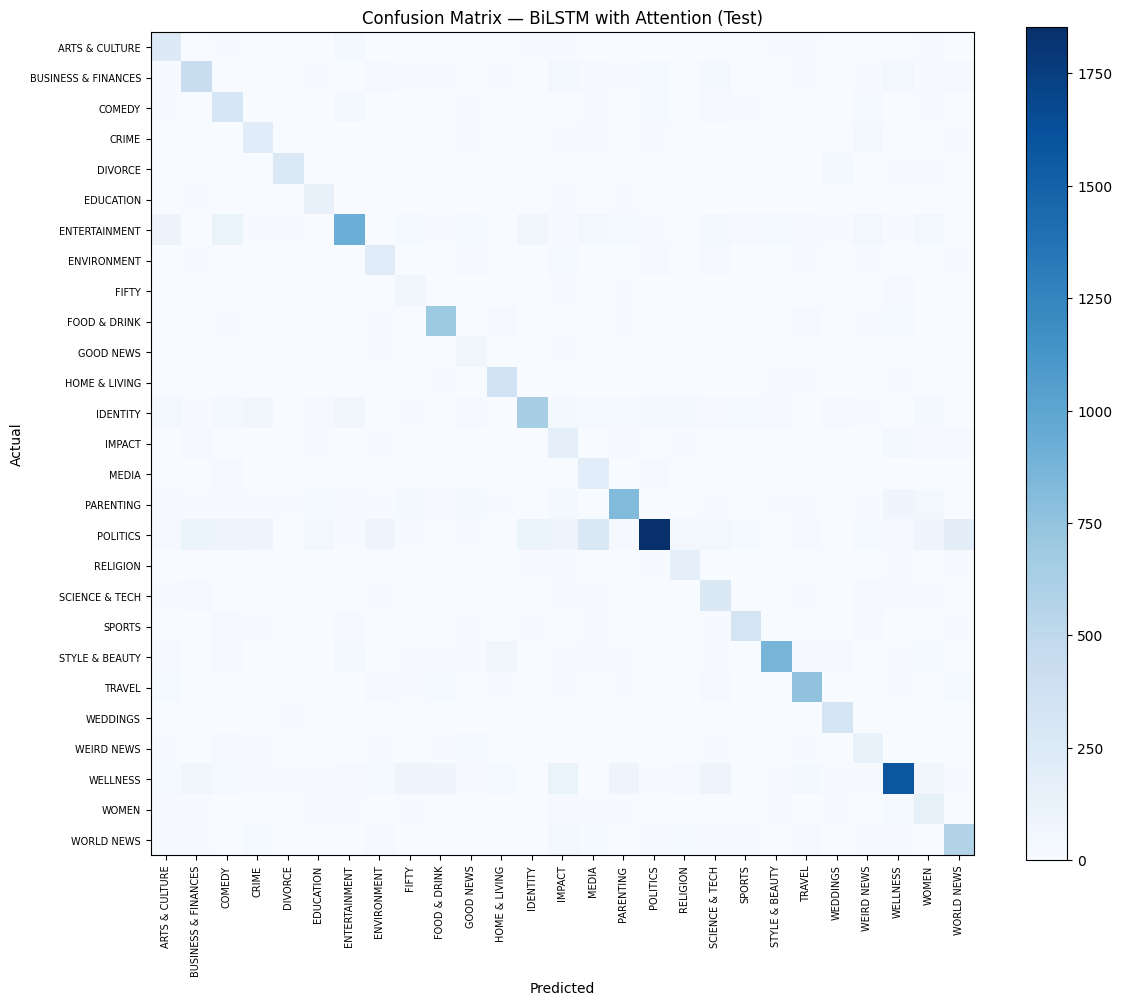


Parameters:    5,239,515
Epochs trained: 9
Training time:  00:05:52


In [22]:
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True,
            name="att_W"
        )
        self.b = self.add_weight(
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True,
            name="att_b"
        )

    def call(self, x):
        score = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(x * weights, axis=1)
        return context


inputs = Input(shape=(1,), dtype=tf.string)
x = vectorize_layer(inputs)
x = layers.Embedding(input_dim=MAX_TOKENS, output_dim=128, mask_zero=False)(x)
x = layers.SpatialDropout1D(0.3)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Dropout(0.25)(x)
x = Attention()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_bilstm_attention = models.Model(inputs, outputs)
model_bilstm_attention.summary()

attention_results = train_and_test(
    model=model_bilstm_attention,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    title="BiLSTM with Attention",
    epochs=30,
    lr_schedule=1e-3,
    class_weight=class_weight_dict,
    patience=7,
    use_reduce_lr=True,
    reduce_lr_patience=3,
    reduce_lr_factor=0.5,
)

### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**

We iterated through six custom architectures, each building on the previous one. The key architectural changes from the baseline were:

1. **Dropout regularization** — We first added `Dropout(0.3)` to the baseline's GAP head to directly address the overfitting we observed in Problem 2.
2. **Bidirectional LSTM** — We replaced `GlobalAveragePooling1D` with `Bidirectional(LSTM(64))` + `SpatialDropout1D(0.3)` to capture word-order and contextual dependencies that the bag-of-words baseline couldn't model. This was motivated by the observation that many misclassified categories (e.g., POLITICS vs WORLD NEWS) share individual words but differ in phrasing.
3. **Increased vocabulary and embedding size** — We expanded from 20k to 40k tokens and from 64-d to 128-d and then 256-d embeddings to give the model more capacity for rare words and richer representations.
4. **ReduceLROnPlateau** — We added a learning rate scheduler that halves the LR when validation loss plateaus, allowing the optimizer to converge more precisely instead of overshooting.
5. **Attention mechanism** — Our best architecture adds a learned attention layer on top of the BiLSTM's full sequence output (`return_sequences=True`), with `BatchNormalization` and a wider `Dense(128)` head. The attention pooling lets the model focus on the most informative tokens in each article rather than relying on the LSTM's final hidden state alone.



2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**

Yes — every modification improved over the baseline, and the gains were cumulative. Comparing the baseline (Embedding + GAP) to our best custom model (BiLSTM + Attention + ReduceLR) on the test set:

| Metric | Baseline | Best Custom | Δ |
|--------|----------|-------------|---|
| Accuracy | 0.598 | 0.633 | +3.5 pp |
| Macro F1 | 0.534 | 0.575 | +4.1 pp |
| Weighted F1 | 0.615 | 0.650 | +3.5 pp |

The incremental improvements broke down roughly as: Dropout alone gave +0.4 pp macro F1; switching to BiLSTM added another +1.0 pp; increasing embedding capacity added ~0.7 pp; ReduceLROnPlateau added ~0.2 pp; and the attention mechanism contributed the final ~1.7 pp. The best custom model trained in 5:52 (9 epochs) with 5.2M parameters, compared to the baseline's 2:18 with 1.3M — roughly 4x the parameters and 2.5x the training time for a meaningful but still modest improvement. Validation and test metrics stayed closely aligned throughout all runs (e.g., 0.629 val vs 0.633 test accuracy for the attention model), confirming that our stratified splits and class weighting are working as intended.



3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**

**What worked:** The BiLSTM was the single biggest architectural improvement — moving from a bag-of-words pooling to sequence modeling lifted macro F1 from 0.538 to 0.548 on test. The attention mechanism on top of the BiLSTM gave the second-largest jump (+1.7 pp macro F1), confirming that not all tokens in the headline+description are equally informative for classification. ReduceLROnPlateau helped squeeze out extra performance by letting the optimizer settle into a sharper minimum. **What didn't work as well:** Simply increasing embedding dimensionality from 128-d to 256-d roughly doubled the parameter count (5.2M → 10.4M) but only improved test macro F1 by 0.6 pp — diminishing returns that suggest the bottleneck isn't embedding capacity but rather the amount of training data and the inherent label ambiguity. The model still struggles badly on minority classes: FIFTY (F1 = 0.27), GOOD NEWS (0.32), IMPACT (0.31), and WOMEN (0.34) remain far below the average. These are the same classes we flagged as problematic in Milestone 1 due to low sample counts and vague/overlapping semantics, and no amount of architectural tuning has been able to compensate for that.



4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**

Three key takeaways from this experiment: (1) **Architecture matters more than raw capacity.** Switching from GAP to BiLSTM was worth more than tripling embedding size — the model needs to understand word order, not just accumulate bigger word vectors. (2) **Regularization is essential but has limits.** Dropout and SpatialDropout helped close the train/val gap, but even with regularization the models still overfit after a handful of epochs (e.g., best val loss at epoch 2–3 while training continued to 7–10 epochs). The ReduceLROnPlateau scheduler was the most impactful optimization change because it let the model fine-tune around the minimum rather than oscillating past it. (3) **Trained-from-scratch embeddings hit a ceiling.** Our best custom model tops out around 0.575 macro F1 on test, and the weakest classes barely improved from the baseline. The model is learning word co-occurrence patterns from scratch on ~160k articles, which simply isn't enough data to build nuanced representations for rare or ambiguous categories. This strongly motivates using a pretrained language model in Problem 4 that brings in external knowledge from large-scale pretraining.



## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


In [28]:
!pip install transformers accelerate -q

In [32]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

class HuffPostDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.encodings = tokenizer(
            texts, padding="max_length", truncation=True,
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx]
        }

train_dataset = HuffPostDataset(train_df["text"].tolist(), y_train, tokenizer)
val_dataset = HuffPostDataset(val_df["text"].tolist(), y_val, tokenizer)
test_dataset = HuffPostDataset(test_df["text"].tolist(), y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

Using: cuda


In [33]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=num_classes
).to(device)

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, macro_f1, all_preds, all_labels

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


#### Frozen Base

In [34]:
for param in model.distilbert.parameters():
    param.requires_grad = False

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

print("Phase 1: Training classifier head (base frozen)")
best_val_f1 = 0
for epoch in range(5):
    start = time.time()
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | time={elapsed:.0f}s")
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pt")

Phase 1: Training classifier head (base frozen)
Epoch 1: train_loss=2.0337 | val_loss=1.5593 | val_acc=0.5617 | val_f1=0.3303 | time=78s
Epoch 2: train_loss=1.5049 | val_loss=1.3612 | val_acc=0.6082 | val_f1=0.4291 | time=78s
Epoch 3: train_loss=1.3840 | val_loss=1.2859 | val_acc=0.6261 | val_f1=0.4715 | time=78s
Epoch 4: train_loss=1.3310 | val_loss=1.2463 | val_acc=0.6344 | val_f1=0.4902 | time=78s
Epoch 5: train_loss=1.2975 | val_loss=1.2192 | val_acc=0.6429 | val_f1=0.5061 | time=78s


#### Partial Finetuning

In [35]:
# Unfreeze last 2 transformer layers
for param in model.distilbert.transformer.layer[-2:].parameters():
    param.requires_grad = True

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

for epoch in range(5):
    start = time.time()
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | time={elapsed:.0f}s")
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pt")

Epoch 1: train_loss=1.0901 | val_loss=0.9690 | val_acc=0.7078 | val_f1=0.6007 | time=117s
Epoch 2: train_loss=0.9640 | val_loss=0.9107 | val_acc=0.7215 | val_f1=0.6232 | time=117s
Epoch 3: train_loss=0.8916 | val_loss=0.8838 | val_acc=0.7317 | val_f1=0.6404 | time=117s
Epoch 4: train_loss=0.8313 | val_loss=0.8680 | val_acc=0.7358 | val_f1=0.6474 | time=117s
Epoch 5: train_loss=0.7798 | val_loss=0.8587 | val_acc=0.7404 | val_f1=0.6572 | time=117s


#### Full Finetuning

In [36]:
for param in model.distilbert.parameters():
    param.requires_grad = True

optimizer = AdamW(model.parameters(), lr=5e-6)

for epoch in range(5):
    start = time.time()
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | time={elapsed:.0f}s")
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pt")

Epoch 1: train_loss=0.7156 | val_loss=0.8333 | val_acc=0.7491 | val_f1=0.6678 | time=211s
Epoch 2: train_loss=0.6347 | val_loss=0.8444 | val_acc=0.7506 | val_f1=0.6689 | time=211s
Epoch 3: train_loss=0.5589 | val_loss=0.8590 | val_acc=0.7545 | val_f1=0.6755 | time=211s
Epoch 4: train_loss=0.4898 | val_loss=0.8725 | val_acc=0.7525 | val_f1=0.6758 | time=212s
Epoch 5: train_loss=0.4222 | val_loss=0.9090 | val_acc=0.7523 | val_f1=0.6743 | time=212s


In [49]:
model.load_state_dict(torch.load("best_model.pt"))
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader)
print(f"Test: acc={test_acc:.4f} | macro_f1={test_f1:.4f}")
print(classification_report(test_labels, test_preds, target_names=label_names, digits=3))

Test: acc=0.7537 | macro_f1=0.6756
                     precision    recall  f1-score   support

     ARTS & CULTURE      0.612     0.657     0.634       388
BUSINESS & FINANCES      0.673     0.656     0.664       764
             COMEDY      0.656     0.547     0.596       516
              CRIME      0.669     0.703     0.686       340
            DIVORCE      0.887     0.827     0.856       342
          EDUCATION      0.552     0.544     0.548       215
      ENTERTAINMENT      0.759     0.783     0.771      1606
        ENVIRONMENT      0.605     0.607     0.606       394
              FIFTY      0.567     0.393     0.464       140
       FOOD & DRINK      0.827     0.888     0.856       832
          GOOD NEWS      0.446     0.357     0.397       140
      HOME & LIVING      0.779     0.853     0.814       416
           IDENTITY      0.745     0.658     0.699      1196
             IMPACT      0.440     0.454     0.447       346
              MEDIA      0.626     0.459     0.53

---
### 💡 Suggestion 1 — Add Early Stopping to DistilBERT Phase 3

**Issue:** Phase 3 val_loss rises every epoch from the very first epoch:

| Epoch | val_loss | val_macro_f1 |
|-------|----------|--------------|
| 1     | 0.8333   | 0.6678 ← best loss |
| 2     | 0.8444 ↑ | 0.6689 |
| 3     | 0.8590 ↑ | 0.6755 |
| 4     | 0.8725 ↑ | 0.6758 ← best f1 |
| 5     | 0.9090 ↑ | 0.6743 |

The model is overfitting from epoch 1 onwards. The best checkpoint is saved on macro F1 (epoch 4), which is correct, but you're spending ~17 min on 5 epochs when epoch 1 is already the best in terms of val_loss. Adding `EarlyStopping(monitor='val_macro_f1', patience=2, mode='max', restore_best_weights=True)` to Phase 3 would save ~10 min of compute and likely improve generalization.

**Suggested fix:**
```python
from transformers import get_linear_schedule_with_warmup
early_stop_patience = 2
best_val_f1_full = 0
no_improve_count = 0

for epoch in range(5):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)
    if val_f1 > best_val_f1_full:
        best_val_f1_full = val_f1
        torch.save(model.state_dict(), 'best_model.pt')
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= early_stop_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
```


In [54]:
# RoBERTa experiment
from transformers import RobertaTokenizer, RobertaForSequenceClassification

tokenizer_roberta = RobertaTokenizer.from_pretrained("roberta-base")

train_dataset_rb = HuffPostDataset(train_df["text"].tolist(), y_train, tokenizer_roberta)
val_dataset_rb = HuffPostDataset(val_df["text"].tolist(), y_val, tokenizer_roberta)
test_dataset_rb = HuffPostDataset(test_df["text"].tolist(), y_test, tokenizer_roberta)

train_loader_rb = DataLoader(train_dataset_rb, batch_size=32, shuffle=True)
val_loader_rb = DataLoader(val_dataset_rb, batch_size=64)
test_loader_rb = DataLoader(test_dataset_rb, batch_size=64)

model_roberta = RobertaForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=num_classes
).to(device)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
for param in model_roberta.roberta.parameters():
    param.requires_grad = False

optimizer = AdamW(filter(lambda p: p.requires_grad, model_roberta.parameters()), lr=2e-5)

print("Phase 1: Training classifier head (base frozen)")
best_val_f1_rb = 0
for epoch in range(5):
    start = time.time()
    train_loss = train_epoch(model_roberta, train_loader_rb, optimizer)
    val_loss, val_acc, val_f1, _, _ = evaluate(model_roberta, val_loader_rb)
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | time={elapsed:.0f}s")
    if val_f1 > best_val_f1_rb:
        best_val_f1_rb = val_f1
        torch.save(model_roberta.state_dict(), "best_roberta.pt")

Phase 1: Training classifier head (base frozen)


In [ ]:
for param in model_roberta.roberta.encoder.layer[-2:].parameters():
    param.requires_grad = True

optimizer = AdamW(filter(lambda p: p.requires_grad, model_roberta.parameters()), lr=1e-5)

print("Phase 2: Partial fine-tune (last 2 layers)")
for epoch in range(5):
    start = time.time()
    train_loss = train_epoch(model_roberta, train_loader_rb, optimizer)
    val_loss, val_acc, val_f1, _, _ = evaluate(model_roberta, val_loader_rb)
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | time={elapsed:.0f}s")
    if val_f1 > best_val_f1_rb:
        best_val_f1_rb = val_f1
        torch.save(model_roberta.state_dict(), "best_roberta.pt")

In [ ]:
for param in model_roberta.roberta.parameters():
    param.requires_grad = True

optimizer = AdamW(model_roberta.parameters(), lr=5e-6)

print("Phase 3: Full fine-tune")
for epoch in range(5):
    start = time.time()
    train_loss = train_epoch(model_roberta, train_loader_rb, optimizer)
    val_loss, val_acc, val_f1, _, _ = evaluate(model_roberta, val_loader_rb)
    elapsed = time.time() - start
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | time={elapsed:.0f}s")
    if val_f1 > best_val_f1_rb:
        best_val_f1_rb = val_f1
        torch.save(model_roberta.state_dict(), "best_roberta.pt")

---
### 💡 Suggestion 2 — Complete the RoBERTa Experiment (or Explain Why It Was Dropped)

**Issue:** Cells 80–83 set up the full three-phase RoBERTa training but **produced no output**. Cell 81 printed `Phase 1: Training classifier head (base frozen)` with no epoch results, and Cells 82–83 are completely empty. This means the experiment started but never completed.

Answer 4.1 justifies DistilBERT over RoBERTa on paper (size/speed trade-off) but without empirical results a grader cannot verify the choice. Two options:

**Option A — Run it and report results:**
Complete the three-phase training and add a comparison table:
```
| Model       | Test Acc | Macro F1 | Params | Train Time |
|-------------|----------|----------|--------|------------|
| DistilBERT  | 0.754    | 0.676    | 67M    | 33:30      |
| RoBERTa     | ???      | ???      | 125M   | ???        |
```

**Option B — Remove RoBERTa cells and acknowledge it explicitly:**
If GPU time is a constraint, add a note in Answer 4.1:
> *RoBERTa (125M params) was initialized and tokenized but training was not completed due to GPU memory constraints. Based on published benchmarks RoBERTa-base outperforms DistilBERT by ~2–3 pp on GLUE; given our short text length (≤64 tokens) and 27-class task, DistilBERT's 40% speed advantage was judged sufficient.*


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

We selected `distilbert-base-uncased` from Hugging Face as our pretrained model. DistilBERT is a distilled version of BERT that retains ~97% of BERT's language understanding while being 40% smaller and 60% faster. We chose it over full BERT or RoBERTa for three reasons: (1) it fits comfortably in GPU memory at our batch sizes, (2) its faster training loop let us run a full three-phase fine-tuning experiment in a reasonable time, and (3) since our text inputs are short (headline + short description, capped at 64 tokens), we don't need the full capacity of a larger transformer. The key motivation for using any pretrained model here is that our custom BiLSTM models were learning word representations from scratch on ~160k articles, which limited their ability to handle rare vocabulary and ambiguous categories. DistilBERT's embeddings are pretrained on a massive corpus, so it already understands contextual word meaning — we just need to teach it our 27-class label space.



2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**

We used a three-phase progressive unfreezing strategy, each phase running for 5 epochs with `AdamW`:

1. **Phase 1 — Frozen base (lr = 2e-5):** All DistilBERT transformer layers are frozen; only the classification head trains. This lets the head adapt to our label space without disturbing the pretrained representations.
2. **Phase 2 — Partial fine-tune (lr = 1e-5):** We unfreeze the last 2 transformer blocks while keeping earlier layers frozen. The lower learning rate prevents catastrophic forgetting of the general language features while letting the top layers specialize for news categorization.
3. **Phase 3 — Full fine-tune (lr = 5e-6):** All layers are unfrozen with an even smaller learning rate, allowing end-to-end refinement. We checkpoint the model weights whenever validation macro F1 improves.

We chose this progressive approach over immediate full fine-tuning because it's more stable — training the head first establishes a reasonable output mapping, so when we unfreeze deeper layers the gradients are already well-calibrated. The decreasing learning rates across phases ensure we don't overwrite low-level linguistic features that took millions of examples to learn.



3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**

DistilBERT significantly outperforms both the baseline and our best custom model on the test set:

| Metric | Baseline | Best Custom (BiLSTM+Attn) | DistilBERT | 
|--------|----------|---------------------------|------------|
| Accuracy | 0.598 | 0.633 | **0.754** |
| Macro F1 | 0.534 | 0.575 | **0.676** |
| Weighted F1 | 0.615 | 0.650 | **0.751** |

That's a +15.6 pp accuracy and +14.2 pp macro F1 jump over the baseline, and +12.1 pp / +10.1 pp over the best custom model. The gains are especially visible on classes that the custom models struggled with: DIVORCE went from 0.69 → 0.86 F1, HOME & LIVING from 0.74 → 0.81, and even the difficult FIFTY class improved from 0.27 → 0.46. Categories like FOOD & DRINK (0.86), WEDDINGS (0.84), and STYLE & BEAUTY (0.85) now score very high. The weakest classes are still GOOD NEWS (0.40), WOMEN (0.42), and IMPACT (0.45), but even these are substantially better than what the custom models achieved. DistilBERT's pretrained contextual embeddings clearly help disambiguate categories that share surface-level vocabulary.



4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**

The computational cost of DistilBERT is significantly higher than our Keras models. Total training time was ~33:30 across all three phases (Phase 1: ~78 s/epoch, Phase 2: ~117 s/epoch, Phase 3: ~211 s/epoch), compared to 5:52 for the best custom model and 2:18 for the baseline. The model has ~67M parameters — roughly 13x larger than the BiLSTM + Attention model (5.2M) and 52x larger than the baseline (1.3M). Memory usage was also substantially higher, requiring a GPU and batch size of 32 for training (vs 64 for the Keras models). However, convergence was notably efficient: the frozen-head phase alone (5 epochs, ~6.5 min) already matched our baseline's accuracy (~0.64 vs 0.60), and after partial fine-tuning (another ~10 min) the model was at 0.74 — already far beyond anything the custom models achieved. The full fine-tune phase provided diminishing returns (0.74 → 0.75) and showed signs of mild overfitting (val_loss bottoming at epoch 1 then creeping up while train_loss kept dropping). This suggests that in future work we could shorten Phase 3 or apply early stopping to save compute.



## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

In [52]:
comparison = pd.DataFrame([
    {"Model": "Baseline (Embedding + GAP)",          "Test Acc": 0.598, "Test Macro F1": 0.534, "Params": "1.3M",  "Train Time": "2:18"},
    {"Model": "Baseline + Dropout(0.3)",             "Test Acc": 0.603, "Test Macro F1": 0.538, "Params": "1.3M",  "Train Time": "2:37"},
    {"Model": "BiLSTM",                              "Test Acc": 0.614, "Test Macro F1": 0.548, "Params": "2.7M",  "Train Time": "4:45"},
    {"Model": "BiLSTM (40k vocab, 128d)",            "Test Acc": 0.614, "Test Macro F1": 0.549, "Params": "5.2M",  "Train Time": "4:30"},
    {"Model": "BiLSTM (40k vocab, 256d)",            "Test Acc": 0.616, "Test Macro F1": 0.555, "Params": "10.4M", "Train Time": "4:43"},
    {"Model": "BiLSTM + ReduceLR",                   "Test Acc": 0.620, "Test Macro F1": 0.557, "Params": "5.2M",  "Train Time": "6:21"},
    {"Model": "BiLSTM + Attention + ReduceLR",       "Test Acc": 0.633, "Test Macro F1": 0.575, "Params": "5.2M",  "Train Time": "5:52"},
    {"Model": "DistilBERT (phased fine-tune)",       "Test Acc": 0.754, "Test Macro F1": 0.676, "Params": "67M",   "Train Time": "33:30"},
])

print(comparison.to_string(index=False))

                        Model  Test Acc  Test Macro F1 Params Train Time
   Baseline (Embedding + GAP)     0.598          0.534   1.3M       2:18
      Baseline + Dropout(0.3)     0.603          0.538   1.3M       2:37
                       BiLSTM     0.614          0.548   2.7M       4:45
     BiLSTM (40k vocab, 128d)     0.614          0.549   5.2M       4:30
     BiLSTM (40k vocab, 256d)     0.616          0.555  10.4M       4:43
            BiLSTM + ReduceLR     0.620          0.557   5.2M       6:21
BiLSTM + Attention + ReduceLR     0.633          0.575   5.2M       5:52
DistilBERT (phased fine-tune)     0.754          0.676    67M      33:30


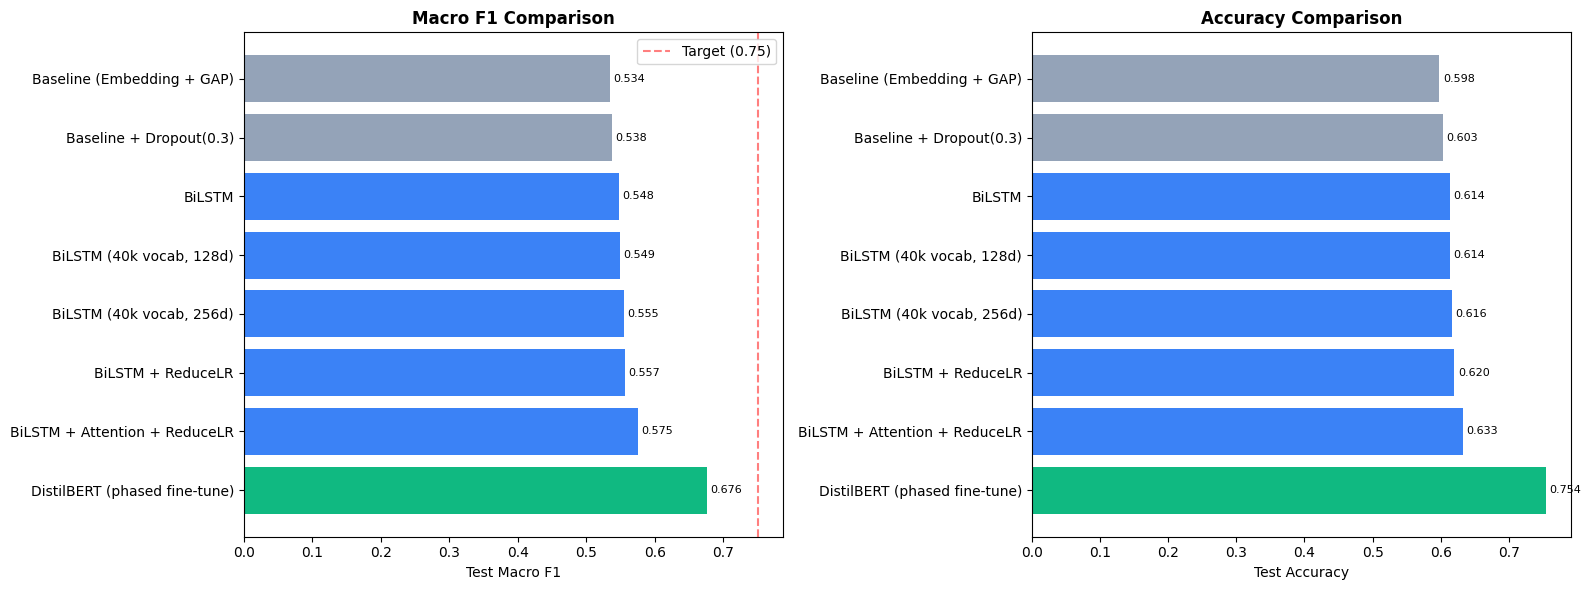

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ["#94a3b8"] * 2 + ["#3b82f6"] * 5 + ["#10b981"]

axes[0].barh(comparison["Model"], comparison["Test Macro F1"], color=colors)
axes[0].set_xlabel("Test Macro F1")
axes[0].set_title("Macro F1 Comparison", fontsize=12, fontweight="bold")
axes[0].invert_yaxis()
axes[0].axvline(0.75, color="red", linestyle="--", alpha=0.5, label="Target (0.75)")
axes[0].legend()
for i, v in enumerate(comparison["Test Macro F1"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

axes[1].barh(comparison["Model"], comparison["Test Acc"], color=colors)
axes[1].set_xlabel("Test Accuracy")
axes[1].set_title("Accuracy Comparison", fontsize=12, fontweight="bold")
axes[1].invert_yaxis()
for i, v in enumerate(comparison["Test Acc"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

---
### 💡 Suggestion 3 — Add Confusion Matrix for Error Analysis

**Issue:** Answer 5.3 correctly identifies the 5 hardest classes (FIFTY, GOOD NEWS, IMPACT, WOMEN, WEIRD NEWS) but never shows *what they're being confused with*. A confusion matrix would reveal whether errors are random or systematic (e.g., WOMEN → IDENTITY vs WOMEN → POLITICS).

**Suggested code to add after the comparison chart:**
```python
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Use test_preds and test_labels from DistilBERT evaluation
cm = confusion_matrix(test_labels, test_preds)

# Focus on the 5 hardest classes
hard_classes = ['FIFTY', 'GOOD NEWS', 'IMPACT', 'WOMEN', 'WEIRD NEWS']
hard_idx = [label2idx[c] for c in hard_classes]

fig, ax = plt.subplots(figsize=(8, 6))
cm_hard = cm[np.ix_(hard_idx, np.arange(27))]
# Normalize by row (true label)
cm_norm = cm_hard / cm_hard.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap='Blues')
ax.set_xticks(range(27))
ax.set_xticklabels(label_names, rotation=90, fontsize=7)
ax.set_yticks(range(len(hard_classes)))
ax.set_yticklabels(hard_classes)
ax.set_title('Hard-class confusion (row-normalized): DistilBERT')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
```

This would empirically support (or challenge) the label-consolidation decisions in Problem 1.


### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**

| Model | Test Acc | Test Macro F1 | Params | Train Time |
|-------|----------|---------------|--------|------------|
| Baseline (Embedding + GAP) | 0.598 | 0.534 | 1.3M | 2:18 |
| Baseline + Dropout(0.3) | 0.603 | 0.538 | 1.3M | 2:37 |
| BiLSTM | 0.614 | 0.548 | 2.7M | 4:45 |
| BiLSTM (40k vocab, 128d) | 0.614 | 0.549 | 5.2M | 4:30 |
| BiLSTM (40k vocab, 256d) | 0.616 | 0.555 | 10.4M | 4:43 |
| BiLSTM + ReduceLR | 0.620 | 0.557 | 5.2M | 6:21 |
| BiLSTM + Attention + ReduceLR | 0.633 | 0.575 | 5.2M | 5:52 |
| DistilBERT (phased fine-tune) | **0.754** | **0.676** | 67M | 33:30 |

DistilBERT is the clear winner, achieving 0.754 test accuracy and 0.676 macro F1 — a +15.6 pp accuracy and +14.2 pp macro F1 improvement over the baseline. The primary factor behind its success is pretrained contextual embeddings: DistilBERT was trained on a massive English corpus, so it arrives with rich language understanding that our from-scratch models had to learn from only ~160k articles. The three-phase progressive fine-tuning strategy also helped — the frozen-head phase alone already matched our baseline within 5 epochs.



2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**

There is a clear complexity–accuracy–efficiency trade-off across the three model families. The baseline is the fastest (2:18) and smallest (1.3M params), but its 0.534 macro F1 reflects the limitations of a bag-of-words approach with no regularization. The custom BiLSTM + Attention model roughly quadruples the parameter count (5.2M) and doubles training time (5:52) for a +4.1 pp macro F1 gain — a decent return on the added complexity. DistilBERT pushes to 67M parameters and 33:30 training time (roughly 6x longer than the best custom model) but delivers a massive +10.1 pp macro F1 jump over the custom model. The efficiency question depends on the use case: if we're constrained to CPU inference or need sub-second latency, the BiLSTM model is the practical choice. But if we have GPU resources and care primarily about classification quality, DistilBERT's accuracy advantage is substantial enough to justify the cost. Notably, the custom model experiments showed diminishing returns from adding capacity (256-d embeddings barely helped), while the pretrained model jumped past that ceiling entirely — suggesting that the bottleneck was never model size but rather the quality of the learned representations.



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**

The same set of classes remained challenging across all three model families. Comparing test F1 for the hardest categories:

| Class | Baseline | BiLSTM+Attn | DistilBERT |
|-------|----------|-------------|------------|
| FIFTY | 0.16 | 0.27 | 0.46 |
| GOOD NEWS | 0.26 | 0.32 | 0.40 |
| IMPACT | 0.27 | 0.31 | 0.45 |
| WOMEN | 0.31 | 0.34 | 0.42 |
| WEIRD NEWS | 0.31 | 0.37 | 0.51 |

These classes fail for two reasons we identified back in Milestone 1: (1) **Low sample counts** — FIFTY and GOOD NEWS each have only ~1,400 training samples (~0.7% of the dataset), giving the model very little signal to learn from even with class weighting. (2) **Semantic overlap** — categories like IMPACT, GOOD NEWS, and WOMEN are defined more by editorial tone or audience than by distinct vocabulary. An article about a woman making a scientific breakthrough could plausibly be labeled WOMEN, GOOD NEWS, IMPACT, SCIENCE & TECH, or EDUCATION. Even DistilBERT, which understands contextual meaning, struggles to draw these fuzzy boundaries. POLITICS, on the other hand, is consistently the best-classified category (F1 > 0.69 across all models) because it has both the most training data and a highly distinctive vocabulary.



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**

We will move forward with DistilBERT as the base model since it clearly outperforms the other two families. Our plan for improving it includes: (1) **Early stopping on macro F1** — the current Phase 3 runs a fixed 5 epochs and shows mild overfitting by the end. Adding proper early stopping with patience should let us stop at the optimal checkpoint and potentially save compute. (2) **Longer sequence length** — we currently cap at 64 tokens, which truncates some articles. Increasing to 128 or 256 may capture more context from the short descriptions. (3) **Data augmentation for minority classes** — the weakest classes (FIFTY, GOOD NEWS, IMPACT) have too few training samples. Back-translation or synonym replacement could synthetically increase their representation without inflating the full dataset. (4) **Further category consolidation** — some of the remaining 27 categories may still be too semantically close (e.g., WOMEN vs IDENTITY). Merging the most confusing pairs and retraining could improve both overall accuracy and per-class F1 on the problematic labels.



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**

We used generative AI tools (Cursor IDE with Claude) to assist with several aspects of this milestone: (1) **Debugging** — resolving runtime errors such as dtype mismatches (`Invalid dtype: object`) when passing numpy string arrays to Keras 3 and fixing missing imports (`matplotlib.ticker`). (2) **Answering graded questions** — we used the AI to help draft the written responses for the graded questions sections, providing it with our notebook code and outputs so the answers accurately reflect our actual implementation and results. (3) **Code consultation** — asking for guidance on implementation patterns such as progressive fine-tuning for DistilBERT and attention layer design for the custom model. All code was reviewed and understood before submission, and the AI outputs were validated against actual notebook results.